<div align="center">

#  Predicción de brotes de dengue en Argentina
## Modelo de aprendizaje automático con variables climáticas y epidemiológicas

---

| | |
|---|---|
| **Integrantes** | *Balda Javier · Caracoix Juan · Casas Facundo* |
| **Institución** | *Universidad Católica Argentina* |
| **Materia / curso** | *Consultoría de datos: Laboratorio III* |
| **Fecha** | Abril 2026 |
| **Datos** | SNVS 2018–2025 (Ministerio de Salud, Argentina) + NASA POWER API |
| **Revista objetivo** | *Revista de Salud UIS* (Universidad Industrial de Santander, Colombia) |

</div>

In [4]:
# @title
from IPython.display import display, HTML
import time

# ============================================================
# CELDA DE PRESENTACIÓN ACADÉMICA — PROYECTO DENGUE ARGENTINA
# Estilo informe científico institucional
# ============================================================

css_estilo = """
<style>
    @import url('https://fonts.googleapis.com/css2?family=Merriweather:ital,wght@0,300;0,400;0,700;1,400&family=Open+Sans:wght@400;600;800&display=swap');

    /* ── Base ───────────────────────────────────────────────────────── */
    .paper-dengue {
        font-family: 'Merriweather', serif;
        color: #2c3e50;
        line-height: 1.85;
        background-color: #ffffff;
        font-size: 15.5px;
        max-width: 960px;
        margin: 30px auto;
        padding: 60px 80px;
        box-shadow: 0 4px 28px rgba(0,0,0,0.09);
        border-top: 10px solid #1D9E75;  /* verde teal del proyecto */
    }

    /* ── Encabezado ─────────────────────────────────────────────────── */
    .header-paper {
        text-align: center;
        border-bottom: 2px solid #1D9E75;
        padding-bottom: 22px;
        margin-bottom: 48px;
    }
    .inst-name {
        font-family: 'Open Sans', sans-serif;
        text-transform: uppercase;
        letter-spacing: 3px;
        color: #666;
        font-size: 0.80rem;
        font-weight: 600;
    }
    .doc-type {
        font-family: 'Open Sans', sans-serif;
        font-weight: 800;
        color: #1D9E75;
        font-size: 1.1rem;
        margin-top: 4px;
        letter-spacing: 1px;
    }
    .doc-subtitle-inst {
        font-size: 0.88rem;
        color: #888;
        margin-top: 4px;
    }

    /* ── Títulos ────────────────────────────────────────────────────── */
    .paper-dengue h1 {
        font-family: 'Open Sans', sans-serif;
        color: #0D1B2A;
        font-size: 2.2rem;
        margin: 22px 0 10px 0;
        line-height: 1.25;
        text-align: center;
        font-weight: 800;
    }
    .paper-title-sub {
        text-align: center;
        font-style: italic;
        color: #666;
        margin-bottom: 38px;
        font-size: 1.05rem;
    }
    .paper-dengue h2 {
        font-family: 'Open Sans', sans-serif;
        color: #0D1B2A;
        border-bottom: 2px solid #1D9E75;
        padding-bottom: 8px;
        margin-top: 52px;
        margin-bottom: 22px;
        font-size: 1.45rem;
        font-weight: 700;
    }
    .paper-dengue h3 {
        font-family: 'Open Sans', sans-serif;
        color: #1D9E75;
        margin-top: 34px;
        margin-bottom: 12px;
        font-size: 1.1rem;
        font-weight: 700;
    }

    /* ── Texto y listas ─────────────────────────────────────────────── */
    .paper-dengue p {
        margin-bottom: 18px;
        text-align: justify;
        color: #333;
    }
    .paper-dengue ul, .paper-dengue ol {
        padding-left: 28px;
        margin-bottom: 18px;
    }
    .paper-dengue li {
        margin-bottom: 9px;
        text-align: justify;
        color: #333;
    }
    .citation { color: #1D9E75; font-weight: 600; }

    /* ── Abstract ───────────────────────────────────────────────────── */
    .abstract-box {
        background: #f4fbf8;
        border-left: 5px solid #1D9E75;
        padding: 24px 28px;
        font-size: 0.94rem;
        margin-bottom: 42px;
        border-radius: 0 6px 6px 0;
    }
    .abstract-box p { margin-bottom: 0; }

    /* ── Cajas de hipótesis ─────────────────────────────────────────── */
    .hipotesis-grid {
        display: grid;
        grid-template-columns: 1fr 1fr;
        gap: 16px;
        margin: 24px 0;
    }
    .hip-card {
        border: 1px solid #d0ede3;
        border-radius: 8px;
        padding: 18px 20px;
        background: #f8fffc;
    }
    .hip-card.principal {
        grid-column: 1 / -1;
        background: #eaf7f2;
        border-color: #1D9E75;
        border-width: 2px;
    }
    .hip-label {
        font-family: 'Open Sans', sans-serif;
        font-size: 0.75rem;
        font-weight: 800;
        text-transform: uppercase;
        letter-spacing: 1.5px;
        color: #1D9E75;
        margin-bottom: 8px;
        display: block;
    }
    .hip-card p { margin-bottom: 0; font-size: 0.93rem; }
    .hip-card.principal p { font-style: italic; font-size: 0.97rem; }

    /* ── Tabla de fuentes ───────────────────────────────────────────── */
    .table-container { overflow-x: auto; margin: 24px 0; border: 1px solid #e0e0e0; border-radius: 6px; }
    .paper-dengue table { width: 100%; border-collapse: collapse; font-family: 'Open Sans', sans-serif; font-size: 0.88rem; }
    .paper-dengue th {
        background-color: #1D9E75;
        color: white;
        padding: 13px 14px;
        text-align: left;
        text-transform: uppercase;
        font-size: 0.75rem;
        letter-spacing: 0.8px;
    }
    .paper-dengue td { border-bottom: 1px solid #eee; padding: 11px 14px; vertical-align: top; }
    .paper-dengue tr:nth-child(even) { background-color: #f8fffe; }
    .paper-dengue tr:hover { background-color: #e8f8f3; }

    /* ── Caja de vacío en literatura ────────────────────────────────── */
    .gap-box {
        background: #fff8e6;
        border: 1px solid #f0c040;
        border-left: 5px solid #BA7517;
        border-radius: 0 6px 6px 0;
        padding: 18px 24px;
        margin: 28px 0;
        font-size: 0.93rem;
    }
    .gap-box strong { color: #BA7517; }

    /* ── Revista objetivo ───────────────────────────────────────────── */
    .revista-box {
        background: #f0f4ff;
        border: 1px solid #bfc8e8;
        border-radius: 8px;
        padding: 22px 28px;
        margin: 24px 0;
    }
    .revista-box .rev-title {
        font-family: 'Open Sans', sans-serif;
        font-weight: 800;
        font-size: 1.05rem;
        color: #2c3a6e;
    }
    .revista-box p { font-size: 0.92rem; margin-bottom: 6px; }

    /* ── Referencias ────────────────────────────────────────────────── */
    .ref-list { font-size: 0.88rem; padding-left: 0; list-style-type: none; }
    .ref-list li {
        margin-bottom: 13px;
        text-indent: -22px;
        padding-left: 22px;
        border-bottom: 1px dotted #e0e0e0;
        padding-bottom: 10px;
        color: #444;
    }
    .ref-list li:last-child { border-bottom: none; }

    /* ── Metadatos de autores ────────────────────────────────────────── */
    .autores-box {
        text-align: center;
        margin: 28px 0 14px 0;
        font-size: 0.93rem;
        color: #555;
    }
    .autores-box .nombres { font-weight: 600; font-family: 'Open Sans', sans-serif; }

    /* ── Footer ─────────────────────────────────────────────────────── */
    .paper-footer {
        text-align: center;
        margin-top: 56px;
        font-size: 0.78rem;
        color: #aaa;
        border-top: 1px solid #eee;
        padding-top: 18px;
        font-family: 'Open Sans', sans-serif;
    }
</style>
"""

html_content = f"""
<!DOCTYPE html>
<html lang="es">
<head>{css_estilo}</head>
<body>
<div class="paper-dengue">

    <!-- ── ENCABEZADO ─────────────────────────────────────────────── -->
    <div class="header-paper">
        <div class="inst-name">[Universidad Católica Argentina] &nbsp;·&nbsp; [Consultoría de datos: Laboratorio III]</div>
        <div class="doc-type">PROPUESTA DE INVESTIGACIÓN CIENTÍFICA</div>
        <div class="doc-subtitle-inst">Área de Ciencia de Datos Aplicada a Salud Pública</div>
    </div>

    <h1>Predicción de brotes de dengue en Argentina mediante aprendizaje automático e integración de variables climáticas y epidemiológicas</h1>

    <div class="paper-title-sub">
        Sistema de alerta temprana departamental · horizonte 2–4 semanas epidemiológicas · datos SNVS 2018–2025
    </div>

    <div class="autores-box">
        <span class="nombres">[Balda Javier] &nbsp;·&nbsp; [Caracoix Juan] &nbsp;·&nbsp; [Casas Facundo]</span><br>
        <span class="linkedin">[linkedin.com/in/javier-balda-821488252] &nbsp;·&nbsp; [linkedin.com/in/juan-caracoix-88523b271] &nbsp;·&nbsp; [linkedin.com/in/facundo-casas-2b6a45270]</span><br>
        Abril 2026
    </div>

    <!-- ── ABSTRACT ───────────────────────────────────────────────── -->
    <div class="abstract-box">
        <p><strong>Resumen:</strong>
        El dengue es la arbovirosis de mayor expansión global, con 390 millones de infecciones anuales estimadas.
        En Argentina, el brote de 2024 fue el más severo de la historia, con 582.267 casos confirmados.
        La detección tardía de los brotes obliga a los sistemas de salud a reaccionar en lugar de anticiparse.
        El presente trabajo propone el desarrollo de un modelo predictivo basado en aprendizaje automático
        (Random Forest, XGBoost) que integra series epidemiológicas semanales del SNVS (2018–2025),
        variables climáticas de NASA POWER y factores socioeconómicos del Censo 2022 para predecir casos
        de dengue por departamento con 2 a 4 semanas de anticipación.
        Se emplea una estrategia de validación walk-forward, utilizando el brote 2024 como conjunto de prueba prospectivo.
        El impacto esperado es la reducción del tiempo de respuesta en fumigación y descacharrización.</p>
    </div>


    <!-- ══════════════════════════════════════════════════════════════ -->
    <h2>1. Introducción y planteamiento del problema</h2>
    <!-- ══════════════════════════════════════════════════════════════ -->

    <p>
    El dengue es una enfermedad viral transmitida por mosquitos del género <em>Aedes aegypti</em> y
    <em>Aedes albopictus</em>, y constituye la arbovirosis de mayor expansión a nivel mundial.
    La Organización Mundial de la Salud estima que se producen aproximadamente 390 millones de infecciones
    anuales en más de 100 países, de las cuales cerca del 75 % son asintomáticas
    (<span class="citation">Bhatt et al., 2013</span>). En América Latina, Brasil, Colombia, Argentina
    y México concentran la mayor carga de enfermedad.
    </p>

    <p>
    En Argentina, la incidencia del dengue ha mostrado una tendencia creciente y sostenida desde 2009,
    con picos epidémicos en 2016, 2020 y 2023. El brote de 2024 superó todos los registros históricos,
    alcanzando 582.267 casos confirmados —más de diez veces el promedio del período 2018–2023—
    y poniendo en evidencia tanto la expansión del vector hacia latitudes históricamente no endémicas
    como la insuficiencia de los sistemas de vigilancia reactivos.
    </p>

    <p>
    Los modelos de vigilancia epidemiológica tradicionales emiten alertas con base en el conteo de casos
    ya confirmados, lo que implica un rezago de 2 a 4 semanas epidemiológicas (SE) entre la notificación
    y la implementación de medidas de control vectorial.
    Este rezago limita significativamente la eficacia de las intervenciones de fumigación y
    descacharrización, que requieren planificación logística previa.
    </p>

    <p>
    Frente a este escenario, el aprendizaje automático ofrece una alternativa promisoria.
    Los modelos entrenados sobre series históricas de casos, combinadas con variables climáticas
    rezagadas —cuya relación con la biología del vector está ampliamente documentada—
    pueden producir predicciones con horizontes de 2 a 4 semanas que anticipen el inicio de los brotes
    con suficiente tiempo para planificar la respuesta sanitaria.
    El presente trabajo propone el desarrollo, evaluación y validación de dicho sistema de alerta temprana
    para Argentina, a nivel de desagregación departamental.
    </p>


    <!-- ══════════════════════════════════════════════════════════════ -->
    <h2>2. Objetivo del proyecto</h2>
    <!-- ══════════════════════════════════════════════════════════════ -->

    <h3>2.1. Objetivo general</h3>
    <p>
    Construir y evaluar un sistema de alerta temprana basado en aprendizaje automático que integre
    series epidemiológicas semanales del SNVS (2018–2025), variables climáticas de NASA POWER y
    factores sociodemográficos del Censo 2022, para predecir la incidencia departamental de dengue
    en Argentina con un horizonte de 2 a 4 semanas epidemiológicas.
    </p>

    <h3>2.2. Objetivos específicos</h3>
    <ol>
        <li>Integrar y normalizar datos heterogéneos provenientes de múltiples fuentes públicas
            (SNVS, NASA POWER, CHIRPS, NDVI vía GEE, INDEC, RENABAP), construyendo un dataset
            maestro departamento × semana epidemiológica.</li>
        <li>Construir un conjunto de <em>features</em> que capture rezagos epidemiológicos,
            climáticos (t−2 a t−6 SE) y contexto socioeconómico estructural.</li>
        <li>Comparar el desempeño de un baseline de media móvil, Random Forest y XGBoost
            mediante validación walk-forward sobre el período 2018–2024.</li>
        <li>Evaluar el sistema prospectivamente sobre el brote 2024 —el más severo registrado—
            como test set natural no visto durante el entrenamiento.</li>
        <li>Producir un mapa de alertas departamental actualizable semanalmente,
            con predicciones a t+2 y t+4 semanas.</li>
    </ol>


    <!-- ══════════════════════════════════════════════════════════════ -->
    <h2>3. Hipótesis y preguntas de investigación</h2>
    <!-- ══════════════════════════════════════════════════════════════ -->

    <p>
    Las hipótesis se formulan de manera contrastable empíricamente, de forma que puedan ser
    aceptadas o rechazadas con base en los resultados cuantitativos del modelo.
    </p>

    <div class="hipotesis-grid">

        <div class="hip-card principal">
            <span class="hip-label">Pregunta experimental principal</span>
            <p>
            ¿Es posible predecir el número de casos semanales de dengue por departamento con 2 a 4 semanas
            de anticipación, alcanzando un <strong>MAPE ≤ 30 %</strong> en departamentos con más de 100 casos
            históricos acumulados, usando variables climáticas rezagadas, índice de vegetación NDVI y
            casos previos, superando un baseline de media móvil histórica?
            </p>
        </div>

        <div class="hip-card">
            <span class="hip-label">H1 — Hipótesis principal</span>
            <p>Un modelo de ensamble (Random Forest / XGBoost) entrenado con lags epidemiológicos y
            variables climáticas rezagadas (t−2 a t−6 SE) alcanza un MAPE significativamente menor
            que una media móvil de 4 semanas en departamentos con más de 100 casos históricos.</p>
        </div>

        <div class="hip-card">
            <span class="hip-label">H2 — Predictor climático dominante</span>
            <p>La temperatura media rezagada 2–4 semanas es el predictor climático de mayor importancia,
            consistente con el ciclo de vida del <em>Aedes aegypti</em> (~14 días entre picadura y viremia).</p>
        </div>

        <div class="hip-card">
            <span class="hip-label">H3 — Variables socioeconómicas</span>
            <p>El índice NBI y la densidad poblacional mejoran la predicción al controlar
            la heterogeneidad socioeconómica entre departamentos, reflejada en la disponibilidad
            de criaderos domiciliarios.</p>
        </div>

        <div class="hip-card">
            <span class="hip-label">H4 — Generalización al brote 2024</span>
            <p>El modelo entrenado en 2018–2023 generaliza al brote 2024 mejor que el baseline,
            demostrando capacidad predictiva en condiciones de brote sin precedentes históricos.</p>
        </div>

    </div>

    <h3>3.1. Preguntas adicionales de análisis</h3>
    <ul>
        <li>¿Qué lag temporal maximiza la correlación entre temperatura/precipitación y casos
            confirmados por semana epidemiológica?</li>
        <li>¿Existen diferencias regionales en la importancia de las variables climáticas
            entre el NOA, la región pampeana y el NEA?</li>
        <li>¿El modelo detecta el inicio del brote (alerta temprana binaria) con precisión
            suficiente para guiar operaciones de fumigación?</li>
    </ul>


    <!-- ══════════════════════════════════════════════════════════════ -->
    <h2>4. Estado del arte y marco conceptual</h2>
    <!-- ══════════════════════════════════════════════════════════════ -->

    <h3>4.1. Epidemiología del dengue y expansión en América Latina</h3>
    <p>
    El dengue es la arbovirosis de mayor crecimiento en incidencia global.
    <span class="citation">Bhatt et al. (2013)</span> estimaron 390 millones de infecciones anuales en
    más de 100 países. La OMS reporta que la incidencia global se multiplicó por diez entre 2000 y 2019.
    En América Latina, la expansión hacia latitudes históricamente no endémicas —incluyendo el sur de Brasil,
    Uruguay y el centro-norte de Argentina— se atribuye principalmente al aumento de temperaturas medias,
    la urbanización acelerada y el deterioro de las condiciones de saneamiento básico.
    </p>
    <p>
    En Argentina, el primer gran brote documentado ocurrió en 2009; desde entonces, la incidencia
    muestra una tendencia creciente con ciclos de intensificación en 2016, 2020 y 2023–2024.
    El brote de 2024 fue particularmente severo: 582.267 casos confirmados, distribución en las 23 provincias
    y afectación de departamentos históricamente no receptivos.
    </p>

    <h3>4.2. Modelos estadísticos clásicos para predicción de dengue</h3>
    <p>
    Los primeros enfoques de predicción se basaron en modelos de series temporales univariados.
    <span class="citation">Luz et al. (2008)</span> analizaron la incidencia de dengue en Río de Janeiro
    mediante modelos ARIMA, estableciendo la primera referencia metodológica sólida para la región.
    Los modelos SARIMA y SARIMAX incorporan posteriormente la estacionalidad y variables climáticas
    exógenas como covariables, mejorando la captura de patrones cíclicos.
    <span class="citation">Racloz et al. (2012)</span> revisaron sistemáticamente los modelos de
    vigilancia y señalaron que los enfoques univariados sub-representan la dinámica espacial y
    las interacciones no lineales entre variables climáticas y epidemiológicas.
    </p>

    <h3>4.3. Aprendizaje automático aplicado a la predicción de brotes</h3>
    <p>
    La incorporación de técnicas de <em>machine learning</em> marcó un punto de inflexión en este campo.
    <span class="citation">Mussumeci y Coelho (2020)</span> compararon modelos LSTM, Random Forest y
    regresión Lasso para predicción a gran escala en Brasil, encontrando que Random Forest ofrecía
    el mejor balance entre precisión e interpretabilidad para horizontes cortos (1–4 semanas).
    <span class="citation">Roster et al. (2022)</span> validaron modelos de ensamble en ciudades
    brasileñas usando variables epidemiológicas y meteorológicas, demostrando que superan a la
    regresión de Poisson en predicción de corto plazo.
    </p>
    <p>
    <span class="citation">Sebastianelli et al. (2024)</span> propusieron un enfoque de ensamble
    reproducible para Brasil con transferibilidad a Perú, estableciendo un marco metodológico
    directamente aplicable al contexto argentino.
    En cuanto a modelos de aprendizaje profundo,
    <span class="citation">Jiménez et al. (2025)</span> desarrollaron un modelo LSTM con SHAP para
    Brasil integrando lags climáticos y efectos espaciales entre estados vecinos, logrando predicciones
    a 4 y 12 semanas con ventanas deslizantes de 7 años de entrenamiento.
    <span class="citation">Ochida et al. (2022)</span> identificaron que la humedad relativa mínima
    y la temperatura máxima son los predictores de mayor importancia en entornos tropicales,
    lo cual fundamenta la selección de los 20 parámetros de NASA POWER utilizados en este trabajo.
    </p>

    <h3>4.4. Rezagos climáticos y biología del vector</h3>
    <p>
    La relación entre variables climáticas y la biología del <em>Aedes aegypti</em> ha sido
    extensamente documentada. La temperatura es el predictor dominante: el ciclo completo de vida
    del vector (huevo → adulto) requiere aproximadamente 7–14 días a 25–30 °C, mientras que el
    período de incubación extrínseca del virus se acorta significativamente por encima de 30 °C
    (<span class="citation">Cabrera et al., 2022</span>).
    Esto fundamenta el uso de rezagos climáticos de 2 a 6 semanas como <em>features</em>,
    consistente con la hipótesis H2 de este trabajo.
    La precipitación acumulada favorece la formación de criaderos, aunque con efectos no lineales:
    precipitaciones muy intensas pueden eliminar larvas por arrastre, lo que motiva el uso tanto
    de la precipitación instantánea como de la acumulada en ventanas de 3 semanas.
    </p>

    <h3>4.5. Revisiones sistemáticas recientes</h3>
    <p>
    <span class="citation">Leung et al. (2023)</span> realizaron la revisión sistemática más completa
    hasta la fecha sobre modelos de predicción de brotes de dengue, analizando 160 estudios.
    Concluyeron que los modelos de aprendizaje automático superan consistentemente a los métodos
    estadísticos clásicos, y que la incorporación de variables ambientales y satelitales (NDVI)
    mejora la precisión especialmente para horizontes de 2–4 semanas.
    <span class="citation">Sylvestre et al. (2022)</span> identificaron en otra revisión sistemática
    que los datos de vigilancia epidemiológica combinados con variables meteorológicas constituyen
    la combinación de inputs más robusta.
    <span class="citation">Mazhar et al. (2024)</span> destacaron que los modelos basados en datos
    reales de vigilancia superan a los modelos teóricos compartimentales (SIR/SEIR) en precisión operativa.
    </p>

    <h3>4.6. Fuentes de datos públicas para modelos predictivos</h3>

    <div class="table-container">
        <table>
            <thead>
                <tr>
                    <th>Fuente</th>
                    <th>Variables</th>
                    <th>Resolución temporal</th>
                    <th>Acceso</th>
                </tr>
            </thead>
            <tbody>
                <tr>
                    <td><strong>SNVS 2.0</strong></td>
                    <td>Casos confirmados de dengue por departamento y semana epidemiológica</td>
                    <td>Semanal — 2013 a la fecha</td>
                    <td>snvs2.msal.gob.ar — descarga directa</td>
                </tr>
                <tr>
                    <td><strong>NASA POWER</strong></td>
                    <td>20 variables: temperatura, humedad, precipitación, radiación, viento</td>
                    <td>Diaria → agregada a semanal</td>
                    <td>power.larc.nasa.gov/api — sin registro</td>
                </tr>
                <tr>
                    <td><strong>CHIRPS</strong></td>
                    <td>Precipitación diaria a resolución 0.05°</td>
                    <td>Diaria — 1981 a la fecha</td>
                    <td>data.chc.ucsb.edu — descarga directa NetCDF</td>
                </tr>
                <tr>
                    <td><strong>Google Earth Engine</strong></td>
                    <td>NDVI mensual (Sentinel-2, 10 m) — proxy de criaderos</td>
                    <td>Mensual (enmascarado de nubes)</td>
                    <td>earthengine.google.com — cuenta gratuita</td>
                </tr>
                <tr>
                    <td><strong>SMN / datos.gob.ar</strong></td>
                    <td>Temperatura extrema diaria por estación (~120 estaciones)</td>
                    <td>Diaria — corrección de sesgo local</td>
                    <td>datos.gob.ar/dataset/smn — descarga directa ZIP</td>
                </tr>
                <tr>
                    <td><strong>INDEC Censo 2022</strong></td>
                    <td>Densidad poblacional, acceso a agua de red, condiciones habitacionales</td>
                    <td>Estático (snapshot 2022)</td>
                    <td>indec.gob.ar/ftp/cuadros/poblacion — XLSX</td>
                </tr>
                <tr>
                    <td><strong>RENABAP</strong></td>
                    <td>Barrios populares: familias, acceso a servicios, georreferenciación</td>
                    <td>Estático (actualización 2022)</td>
                    <td>datosabiertos.desarrollosocial.gob.ar — CSV/GeoJSON</td>
                </tr>
            </tbody>
        </table>
    </div>

    <h3>4.7. Vacío en la literatura y aporte de este trabajo</h3>

    <div class="gap-box">
        <strong>Vacío identificado:</strong> La mayoría de los estudios existentes se focalizan en Brasil,
        Colombia o países del sudeste asiático.
        No se identificaron publicaciones que apliquen modelos de aprendizaje automático con validación
        walk-forward al sistema de vigilancia argentino (SNVS) utilizando datos departamentales reales,
        ni que evalúen el brote 2024 como conjunto de prueba prospectivo.
        Este trabajo busca cubrir ese vacío, constituyendo el primer análisis sistemático de predicción
        departamental de dengue en Argentina con datos reales 2018–2025 y test set sobre el mayor
        brote registrado en el país.
    </div>


    <!-- ══════════════════════════════════════════════════════════════ -->
    <h2>5. Revista objetivo</h2>
    <!-- ══════════════════════════════════════════════════════════════ -->

    <div class="revista-box">
        <div class="rev-title">Revista de Salud UIS — Universidad Industrial de Santander, Colombia</div>
        <p style="margin-top:10px;">
            <strong>ISSN impreso:</strong> 0121-0807 &nbsp;·&nbsp;
            <strong>ISSN electrónico:</strong> 2145-8464 &nbsp;·&nbsp;
            <strong>Periodicidad:</strong> Trimestral
        </p>
        <p>
            <strong>Indexación:</strong> SciELO Colombia, Redalyc, LILACS, Latindex Catálogo 2.0
        </p>
        <p>
            <strong>Alcance:</strong> Salud pública, epidemiología, medicina preventiva y ciencias de la salud
            con énfasis en América Latina.
        </p>
        <p>
            <strong>Justificación:</strong> El alcance de la revista coincide directamente con el contenido
            de este trabajo: modelado predictivo de enfermedades transmisibles con impacto en salud pública
            regional. La indexación en SciELO y LILACS garantiza visibilidad en la región donde se producen
            los brotes estudiados. El enfoque metodológico cuantitativo con datos reales de vigilancia
            sanitaria se alinea con el perfil de trabajos publicados recientemente en la revista.
        </p>
        <p>
            🔗 <a href="https://revistas.uis.edu.co/index.php/revistasaluduis" target="_blank">
            revistas.uis.edu.co/index.php/revistasaluduis</a>
        </p>
    </div>


    <!-- ══════════════════════════════════════════════════════════════ -->
    <h2>6. Referencias bibliográficas</h2>
    <!-- ══════════════════════════════════════════════════════════════ -->

    <ul class="ref-list">
        <li><strong>Bhatt, S., Gething, P. W., Brady, O. J., Messina, J. P., Farlow, A. W., Moyes, C. L.,
            ... &amp; Hay, S. I.</strong> (2013). The global distribution and burden of dengue.
            <em>Nature</em>, <em>496</em>(7446), 504–507.
            https://doi.org/10.1038/nature12060</li>

        <li><strong>Cabrera, M., Leake, J., Naranjo-Torres, J., Valero, N., Cabrera, J. C., &amp;
            Rodríguez-Morales, A. J.</strong> (2022). When climate variables improve the dengue forecasting:
            A machine learning approach.
            <em>The European Physical Journal Special Topics</em>, <em>231</em>, 3473–3485.
            https://doi.org/10.1140/epjs/s11734-024-01201-7</li>

        <li><strong>Jiménez, L., Costa, G. P., &amp; Silva, F. R.</strong> (2025). Forecasting dengue across
            Brazil with LSTM neural networks and SHAP-driven lagged climate and spatial effects.
            <em>BMC Public Health</em>, <em>25</em>, 892.
            https://doi.org/10.1186/s12889-025-22106-7</li>

        <li><strong>Leung, X. Y., Islam, R. M., Adhami, M., Ilic, D., McDonald, L., Palawaththa, S.,
            ... &amp; Karim, M. N.</strong> (2023). A systematic review of dengue outbreak prediction models:
            Current scenario and future directions.
            <em>PLOS Neglected Tropical Diseases</em>, <em>17</em>(2), e0010631.
            https://doi.org/10.1371/journal.pntd.0010631</li>

        <li><strong>Luz, P. M., Mendes, B. V. M., Codeço, C. T., Struchiner, C. J., &amp; Galvani, A. P.</strong>
            (2008). Time series analysis of dengue incidence in Rio de Janeiro, Brazil.
            <em>The American Journal of Tropical Medicine and Hygiene</em>, <em>79</em>(6), 933–939.
            https://doi.org/10.4269/ajtmh.2008.79.933</li>

        <li><strong>Mazhar, B., Mazhar Ali, N., Manzoor, F., Khan, M. K., Nasir, M., &amp; Ramzan, M.</strong>
            (2024). Development of data-driven machine learning models and their potential role in predicting
            dengue outbreak.
            <em>Journal of Vector Borne Diseases</em>, <em>61</em>(4), 503–514.
            https://doi.org/10.4103/0972-9062.393976</li>

        <li><strong>Mussumeci, E., &amp; Coelho, F. C.</strong> (2020). Large-scale multivariate forecasting
            models for dengue – LSTM versus random forest regression.
            <em>Spatial and Spatio-temporal Epidemiology</em>, <em>35</em>, 100372.
            https://doi.org/10.1016/j.sste.2020.100372</li>

        <li><strong>Ochida, N., Mangeas, M., Dupont-Rouzeyrol, M., Dutheil, C., Forfait, C., Peltier, A.,
            Descloux, E., &amp; Menkes, C.</strong> (2022). Identification of significant climatic risk factors
            and machine learning models in dengue outbreak prediction.
            <em>BMC Medical Informatics and Decision Making</em>, <em>21</em>, 141.
            https://doi.org/10.1186/s12911-021-01493-y</li>

        <li><strong>Racloz, V., Ramsey, R., Tong, S., &amp; Hu, W.</strong> (2012). Surveillance of dengue
            fever virus: A review of epidemiological models and early warning systems.
            <em>PLOS Neglected Tropical Diseases</em>, <em>6</em>(5), e1648.
            https://doi.org/10.1371/journal.pntd.0001648</li>

        <li><strong>Roster, K., Connaughton, C., &amp; Rodrigues, F. A.</strong> (2022).
            Machine-learning–based forecasting of dengue fever in Brazilian cities using epidemiologic
            and meteorological variables.
            <em>American Journal of Epidemiology</em>, <em>191</em>(10), 1803–1812.
            https://doi.org/10.1093/aje/kwac090</li>

        <li><strong>Sebastianelli, A., Spiller, D., Carmo, R., Wheeler, J., Nowakowski, A., Jacobson, L. V.,
            ... &amp; Lowe, R.</strong> (2024). A reproducible ensemble machine learning approach to forecast
            dengue outbreaks.
            <em>Scientific Reports</em>, <em>14</em>, 3807.
            https://doi.org/10.1038/s41598-024-52796-9</li>

        <li><strong>Sylvestre, E., Joachim, C., Cécilia-Joseph, E., Bouzillé, G., Campillo-Gimenez, B.,
            Cuggia, M., &amp; Cabié, A.</strong> (2022). Data-driven methods for dengue prediction and
            surveillance using real-world and Big Data: A systematic review.
            <em>PLOS Neglected Tropical Diseases</em>, <em>16</em>(1), e0010056.
            https://doi.org/10.1371/journal.pntd.0010056</li>
    </ul>

    <!-- ── FOOTER ─────────────────────────────────────────────────── -->
    <div class="paper-footer">
        Documento generado automáticamente · Proyecto de predicción de dengue en Argentina ·
        Versión de propuesta {time.strftime("%d/%m/%Y")}
    </div>

</div>
</body>
</html>
"""

display(HTML(html_content))

Fuente,Variables,Resolución temporal,Acceso
SNVS 2.0,Casos confirmados de dengue por departamento y semana epidemiológica,Semanal — 2013 a la fecha,snvs2.msal.gob.ar — descarga directa
NASA POWER,"20 variables: temperatura, humedad, precipitación, radiación, viento",Diaria → agregada a semanal,power.larc.nasa.gov/api — sin registro
CHIRPS,Precipitación diaria a resolución 0.05°,Diaria — 1981 a la fecha,data.chc.ucsb.edu — descarga directa NetCDF
Google Earth Engine,"NDVI mensual (Sentinel-2, 10 m) — proxy de criaderos",Mensual (enmascarado de nubes),earthengine.google.com — cuenta gratuita
SMN / datos.gob.ar,Temperatura extrema diaria por estación (~120 estaciones),Diaria — corrección de sesgo local,datos.gob.ar/dataset/smn — descarga directa ZIP
INDEC Censo 2022,"Densidad poblacional, acceso a agua de red, condiciones habitacionales",Estático (snapshot 2022),indec.gob.ar/ftp/cuadros/poblacion — XLSX
RENABAP,"Barrios populares: familias, acceso a servicios, georreferenciación",Estático (actualización 2022),datosabiertos.desarrollosocial.gob.ar — CSV/GeoJSON


##  Tabla de contenidos

1. [Objetivo del proyecto](#objetivo)
2. [Hipótesis y preguntas de investigación](#hipotesis)
3. [Estado del arte](#estado-del-arte)
4. [Revista objetivo](#revista)
5. [Configuración del entorno](#config)
6. [Ingesta de datos — SNVS](#snvs)
7. [Ingesta de datos — NASA POWER API](#nasa)
8. [Calidad y limpieza de datos](#limpieza)
9. [Dataset limpio — exportación](#exportacion)
10. [Análisis exploratorio (EDA)](#eda)
11. [Feature engineering](#features)
12. [Modelo baseline y modelo candidato](#modelos)
13. [Validación walk-forward](#validacion)
14. [Resultados e interpretabilidad](#resultados)

---
<a id="objetivo"></a>

##  1. Objetivo del proyecto

Este proyecto tiene como objetivo desarrollar un **modelo predictivo de brotes de dengue a nivel departamental en Argentina**, capaz de anticipar el número de casos confirmados con **2 a 4 semanas de anticipación**, utilizando exclusivamente datos de acceso público.

### Objetivo general

Construir y evaluar un sistema de alerta temprana basado en aprendizaje automático que integre series epidemiológicas semanales del SNVS (2018–2025), variables climáticas de NASA POWER y factores sociodemográficos del Censo 2022, para predecir la incidencia departamental de dengue en Argentina.

### Objetivos específicos

1. Integrar y normalizar datos heterogéneos provenientes de múltiples fuentes públicas (SNVS, NASA POWER, INDEC).
2. Construir un conjunto de features que capture rezagos epidemiológicos, climáticos y contexto socioeconómico.
3. Comparar el desempeño de modelos de referencia (media móvil, Random Forest, XGBoost) mediante validación walk-forward.
4. Evaluar el sistema sobre el brote 2024 —el más severo de la historia argentina— como test prospectivo.
5. Producir un mapa de alertas departamental actualizable semanalmente.

---
<a id="hipotesis"></a>

##  2. Hipótesis y preguntas de investigación

### Pregunta experimental principal

> ¿Es posible predecir el número de casos semanales de dengue por departamento con 2 a 4 semanas de anticipación, alcanzando un **MAPE ≤ 30 %** en departamentos con más de 100 casos históricos acumulados, usando variables climáticas rezagadas, índice de vegetación NDVI y casos previos, superando un baseline de media móvil histórica?

### Hipótesis principal

**H1:** Un modelo de ensamble (Random Forest / XGBoost) entrenado con lags epidemiológicos y variables climáticas rezagadas (t−2 a t−6 semanas) alcanza un MAPE significativamente menor que una media móvil de 4 semanas en departamentos con más de 100 casos históricos.

### Hipótesis secundarias

**H2:** La temperatura media rezagada 2–4 semanas es el predictor climático de mayor importancia, consistente con el ciclo de vida del *Aedes aegypti* (~14 días entre picadura y viremia).

**H3:** El índice NBI (Necesidades Básicas Insatisfechas) y la densidad poblacional mejoran la predicción al controlar heterogeneidad socioeconómica entre departamentos.

**H4:** El modelo entrenado en 2018–2023 generaliza al brote 2024 mejor que el baseline, demostrando capacidad predictiva en condiciones de brote sin precedentes.

### Preguntas adicionales de análisis

- ¿Qué lag temporal maximiza la correlación entre temperatura/precipitación y casos?
- ¿Existen diferencias regionales en la importancia de las variables climáticas (NOA vs. región pampeana vs. NEA)?
- ¿El modelo detecta el inicio del brote (alerta temprana binaria) con precisión suficiente para guiar operaciones de fumigación?

---
<a id="estado-del-arte"></a>

##  3. Estado del arte y marco conceptual

### 3.1 Epidemiología del dengue y contexto global

El dengue es la arbovirosis de mayor expansión a nivel mundial, con aproximadamente 390 millones de infecciones anuales en más de 100 países (Bhatt et al., 2013). La Organización Mundial de la Salud reporta que la incidencia global se multiplicó por diez entre 2000 y 2019. En América Latina, Brasil, Colombia, Argentina y México concentran la mayor carga de enfermedad. Argentina registró en 2024 su brote más severo, con 582.267 casos confirmados, lo que pone en evidencia la expansión del vector hacia latitudes históricamente no endémicas.

### 3.2 Modelos estadísticos clásicos

Los primeros enfoques predictivos se basaron en modelos de series temporales univariados. Luz et al. (2008) analizaron la incidencia de dengue en Río de Janeiro mediante modelos ARIMA, estableciendo una de las primeras referencias metodológicas para la región. Los modelos SARIMA y SARIMAX incorporan posteriormente la estacionalidad y variables climáticas exógenas (temperatura, humedad), mejorando la captura de patrones cíclicos. Racloz et al. (2012) revisaron sistemáticamente los modelos de vigilancia epidemiológica y señalaron que los enfoques univariados sub-representan la dinámica espacial y las interacciones entre variables.

### 3.3 Aprendizaje automático aplicado a la predicción de dengue

La incorporación de técnicas de machine learning marcó un punto de inflexión. Mussumeci y Coelho (2020) compararon modelos LSTM, Random Forest y regresión Lasso para predicción a gran escala en Brasil, encontrando que Random Forest ofrecía el mejor balance entre precisión y interpretabilidad para horizontes cortos (1–4 semanas). Roster et al. (2022) validaron modelos de machine learning en ciudades brasileñas usando variables epidemiológicas y meteorológicas, destacando que los modelos de ensamble superan a la regresión de Poisson en predicción de corto plazo. Salim et al. (2021) evaluaron SVM, árbol de decisión y redes neuronales para Selangor (Malasia), alcanzando 70% de precisión con SVM; sin embargo, los modelos de ensamble como XGBoost y Random Forest superaron a los clasificadores individuales (Patil y Pandya, 2021; Mazhar et al., 2024).

Sebastianelli et al. (2024) propusieron un enfoque de ensamble reproducible para Brasil, demostrando transferibilidad a Perú y estableciendo un marco metodológico aplicable a Argentina. Más recientemente, Jiménez et al. (2025) desarrollaron un modelo LSTM con SHAP para Brasil que integra lags climáticos y efectos espaciales entre estados vecinos, logrando predicciones a 4 y 12 semanas con ventanas deslizantes de 7 años de entrenamiento.

### 3.4 Variables climáticas y rezagos temporales

La temperatura es el predictor climático dominante en la biología del *Aedes aegypti*: el ciclo completo de vida (huevo → adulto) tarda aproximadamente 7–14 días a 25–30°C, mientras que el período de incubación extrínseca del virus se acorta drásticamente por encima de 30°C. Esto fundamenta el uso de rezagos climáticos de 2–6 semanas como features (Cabrera et al., 2022; Salim et al., 2021). La precipitación acumulada favorece la formación de criaderos, aunque con efectos no lineales: precipitaciones muy intensas pueden eliminar larvas por arrastre. Ochida et al. (2022) identificaron que la humedad relativa mínima y la temperatura máxima son los predictores climáticos de mayor importancia en contextos tropicales.

### 3.5 Revisiones sistemáticas recientes

Leung et al. (2023) realizaron la revisión sistemática más completa hasta la fecha sobre modelos de predicción de brotes de dengue, analizando 160 estudios. Concluyeron que los modelos de aprendizaje automático superan consistentemente a los métodos estadísticos clásicos, y que la incorporación de variables ambientales y satelitales (NDVI) mejora la precisión, especialmente para horizontes de 2–4 semanas. Sylvestre et al. (2022) identificaron en otra revisión sistemática que los datos de vigilancia epidemiológica combinados con variables meteorológicas constituyen la combinación de inputs más robusta. Mazhar et al. (2024) destacaron que los modelos basados en datos reales de vigilancia (como el SNVS de Argentina) superan a los modelos teóricos compartimentales (SIR/SEIR) en precisión operativa.

### 3.6 Vacío en la literatura y aporte de este trabajo

La mayoría de los estudios existentes se focalizan en Brasil, Colombia o países del sudeste asiático. **No se identificaron publicaciones que apliquen modelos de machine learning con validación walk-forward al sistema de vigilancia argentino (SNVS) utilizando datos departamentales reales**, ni que evalúen el brote 2024 como test prospectivo. Este trabajo busca cubrir ese vacío, constituyendo el primer análisis sistemático de predicción departamental de dengue en Argentina con datos reales 2018–2025.

---

### Referencias (formato APA 7.ª edición)

Bhatt, S., Gething, P. W., Brady, O. J., Messina, J. P., Farlow, A. W., Moyes, C. L., Drake, J. M., Brownstein, J. S., Hoen, A. G., Sankoh, O., Myers, M. F., George, D. B., Jaenisch, T., Wint, G. R. W., Simmons, C. P., Scott, T. W., Farrar, J. J., & Hay, S. I. (2013). The global distribution and burden of dengue. *Nature*, *496*(7446), 504–507. https://doi.org/10.1038/nature12060

Cabrera, M., Leake, J., Naranjo-Torres, J., Valero, N., Cabrera, J. C., & Rodríguez-Morales, A. J. (2022). When climate variables improve the dengue forecasting: A machine learning approach. *The European Physical Journal Special Topics*, *231*, 3473–3485. https://doi.org/10.1140/epjs/s11734-024-01201-7

Jiménez, L., Costa, G. P., & Silva, F. R. (2025). Forecasting dengue across Brazil with LSTM neural networks and SHAP-driven lagged climate and spatial effects. *BMC Public Health*, *25*, 892. https://doi.org/10.1186/s12889-025-22106-7

Leung, X. Y., Islam, R. M., Adhami, M., Ilic, D., McDonald, L., Palawaththa, S., Diug, B., Munshi, S. U., & Karim, M. N. (2023). A systematic review of dengue outbreak prediction models: Current scenario and future directions. *PLOS Neglected Tropical Diseases*, *17*(2), e0010631. https://doi.org/10.1371/journal.pntd.0010631

Luz, P. M., Mendes, B. V. M., Codeço, C. T., Struchiner, C. J., & Galvani, A. P. (2008). Time series analysis of dengue incidence in Rio de Janeiro, Brazil. *The American Journal of Tropical Medicine and Hygiene*, *79*(6), 933–939. https://doi.org/10.4269/ajtmh.2008.79.933

Mazhar, B., Mazhar Ali, N., Manzoor, F., Khan, M. K., Nasir, M., & Ramzan, M. (2024). Development of data-driven machine learning models and their potential role in predicting dengue outbreak. *Journal of Vector Borne Diseases*, *61*(4), 503–514. https://doi.org/10.4103/0972-9062.393976

Mussumeci, E., & Coelho, F. C. (2020). Large-scale multivariate forecasting models for dengue – LSTM versus random forest regression. *Spatial and Spatio-temporal Epidemiology*, *35*, 100372. https://doi.org/10.1016/j.sste.2020.100372

Ochida, N., Mangeas, M., Dupont-Rouzeyrol, M., Dutheil, C., Forfait, C., Peltier, A., Descloux, E., & Menkes, C. (2022). Identification of significant climatic risk factors and machine learning models in dengue outbreak prediction. *BMC Medical Informatics and Decision Making*, *21*, 141. https://doi.org/10.1186/s12911-021-01493-y

Patil, S., & Pandya, S. (2021). Forecasting dengue hotspots associated with variation in meteorological parameters using regression and time series models. *Frontiers in Public Health*, *9*, 798034. https://doi.org/10.3389/fpubh.2021.798034

Racloz, V., Ramsey, R., Tong, S., & Hu, W. (2012). Surveillance of dengue fever virus: A review of epidemiological models and early warning systems. *PLOS Neglected Tropical Diseases*, *6*(5), e1648. https://doi.org/10.1371/journal.pntd.0001648

Roster, K., Connaughton, C., & Rodrigues, F. A. (2022). Machine-learning–based forecasting of dengue fever in Brazilian cities using epidemiologic and meteorological variables. *American Journal of Epidemiology*, *191*(10), 1803–1812. https://doi.org/10.1093/aje/kwac090

Salim, N. A. M., Wah, Y. B., Reeves, C., Smith, M., Yaacob, W. F. W., Mudin, R. N., Dapari, R., Sapri, N. N. F. F., & Haque, U. (2021). Prediction of dengue outbreak in Selangor Malaysia using machine learning techniques. *Scientific Reports*, *11*, 939. https://doi.org/10.1038/s41598-020-79193-2

Sebastianelli, A., Spiller, D., Carmo, R., Wheeler, J., Nowakowski, A., Jacobson, L. V., Kim, D., Barlevi, H., Cordero, Z. E., Colón-González, F. J., & Lowe, R. (2024). A reproducible ensemble machine learning approach to forecast dengue outbreaks. *Scientific Reports*, *14*, 3807. https://doi.org/10.1038/s41598-024-52796-9

Sylvestre, E., Joachim, C., Cécilia-Joseph, E., Bouzillé, G., Campillo-Gimenez, B., Cuggia, M., & Cabié, A. (2022). Data-driven methods for dengue prediction and surveillance using real-world and Big Data: A systematic review. *PLOS Neglected Tropical Diseases*, *16*(1), e0010056. https://doi.org/10.1371/journal.pntd.0010056

---
<a id="revista"></a>

##  4. Revista objetivo

**Revista de Salud UIS** — Universidad Industrial de Santander, Colombia  
🔗 https://revistas.uis.edu.co/index.php/revistasaluduis

| Campo | Detalle |
|---|---|
| **ISSN impreso** | 0121-0807 |
| **ISSN electrónico** | 2145-8464 |
| **Indexación** | SciELO Colombia, Redalyc, LILACS, Latindex Catálogo |
| **Idioma** | Español (resumen en inglés) |
| **Periodicidad** | Trimestral |
| **Alcance** | Salud pública, epidemiología, medicina preventiva, ciencias de la salud |
| **Formato de citación** | Vancouver / APA |

### Justificación de la elección

La *Revista de Salud UIS* es un espacio de publicación reconocido en América Latina para estudios de epidemiología aplicada y salud pública. Su alcance temático coincide directamente con el contenido de este trabajo: modelado predictivo de enfermedades transmisibles con impacto en salud pública regional. La indexación en SciELO y LILACS garantiza visibilidad en la región donde se producen los brotes estudiados. Además, el enfoque metodológico cuantitativo con datos reales de vigilancia sanitaria se alinea con el perfil de trabajos publicados recientemente en la revista.

---
<a id="config"></a>

##  5. Configuración del entorno

---
<a id="config"></a>

##  5. Configuración del entorno

In [5]:
# Instalar dependencias no incluidas en Colab por defecto
%pip install -q xgboost


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
# Instalar dependencias necesarias
%pip install -q pandas numpy matplotlib seaborn requests scikit-learn xgboost


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import requests
import warnings
import json
import time
import unicodedata
from io import StringIO
from pathlib import Path
from datetime import datetime

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 30)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = ['#1D9E75', '#7F77DD', '#D85A30', '#BA7517', '#378ADD']

print(f'Entorno configurado — {datetime.now().strftime("%Y-%m-%d %H:%M")}')
print(f'pandas {pd.__version__} | numpy {np.__version__} | xgboost {xgb.__version__}')

Entorno configurado — 2026-04-14 15:02
pandas 3.0.2 | numpy 2.4.4 | xgboost 3.2.0


In [8]:
BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name == 'notebooks' and (BASE_DIR.parent / 'data').exists():
    BASE_DIR = BASE_DIR.parent
DATA_DIR = BASE_DIR / 'data'
OUT_DIR = BASE_DIR / 'data'
print(f'Directorio de datos: {DATA_DIR}')
print(f'Directorio de salida: {OUT_DIR}')


Directorio de datos: /workspaces/prediccion_dengue/data
Directorio de salida: /workspaces/prediccion_dengue/data


---
<a id="snvs"></a>

##  6. Ingesta de datos — SNVS

El **Sistema Nacional de Vigilancia de la Salud (SNVS 2.0)** publica casos confirmados de dengue por departamento y semana epidemiológica desde 2018.  
URL: https://snvs2.msal.gob.ar

Los archivos presentan **dos esquemas de columnas** según el año:

| Esquema | Años | Columnas clave |
|---|---|---|
| **A (original)** | 2018–2022 | `departamento_nombre`, `semanas_epidemiologicas`, `cantidad_casos` |
| **B (nuevo)** | 2023–2025 | `departamento_residencia`, `sepi_min`, `cantidad` |

La función `load_snvs_file()` detecta el esquema automáticamente.

In [9]:
# ── Mapas de normalización de columnas ────────────────────────────────────────
SCHEMA_A = {
    'departamento_id':         'depto_id',
    'departamento_nombre':     'departamento',
    'provincia_id':            'prov_id',
    'provincia_nombre':        'provincia',
    'año':                     'anio',
    'ano':                     'anio',
    'semanas_epidemiologicas': 'semana',
    'evento_nombre':           'evento',
    'grupo_edad_id':           'grupo_edad_id',
    'grupo_edad_desc':         'grupo_edad_desc',
    'cantidad_casos':          'cantidad_casos',
}
SCHEMA_B = {
    'id_depto_indec_residencia':  'depto_id',
    'departamento_residencia':    'departamento',
    'id_prov_indec_residencia':   'prov_id',
    'provincia_residencia':       'provincia',
    'anio_min':                   'anio',
    'evento':                     'evento',
    'id_grupo_etario':            'grupo_edad_id',
    'grupo_etario':               'grupo_edad_desc',
    'sepi_min':                   'semana',
    'cantidad':                   'cantidad_casos',
}

def _clean_col(c: str) -> str:
    return c.strip().lstrip('\ufeff').strip('"').lower().replace('ï»¿', '')


def load_snvs_file(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == '.csv':
        df = pd.read_csv(path, encoding='latin-1', sep=None, engine='python')
    elif suffix in ('.xlsx', '.xls'):
        df = pd.read_excel(path)
    else:
        raise ValueError(f'Formato no soportado: {suffix}')

    df.columns = [_clean_col(c) for c in df.columns]

    rename = {}
    for col in df.columns:
        if col in SCHEMA_A:   rename[col] = SCHEMA_A[col]
        elif col in SCHEMA_B: rename[col] = SCHEMA_B[col]
    df = df.rename(columns=rename)

    if 'evento' in df.columns:
        df = df[df['evento'].astype(str).str.lower().str.strip() == 'dengue'].copy()

    key_cols = [c for c in ['anio', 'semana', 'depto_id', 'departamento',
                             'prov_id', 'provincia'] if c in df.columns]
    df = df.groupby(key_cols, as_index=False)['cantidad_casos'].sum()

    df['anio']           = df['anio'].astype(float).astype(int)
    df['semana']         = df['semana'].astype(float).astype(int)
    df['cantidad_casos'] = df['cantidad_casos'].astype(float).astype(int)
    return df


print('Funciones de normalización SNVS definidas.')

Funciones de normalización SNVS definidas.


In [10]:
ARCHIVOS_SNVS = [
    'dengue-zika-nacional-2018.csv',
    'dengue-zika-nacional-2019.xlsx',
    'dengue-zika-nacional-2020.xlsx',
    'dengue-zika-nacional-2021.xlsx',
    'dengue-zika-nacional-2022.csv',
    'dengue-zika-nacional-2023.csv',
    'dengue-zika-nacional-2024.csv',
    'dengue-zika-nacional-2025-primer-semestre.csv',
    'dengue-zika-nacional-2025-segundo-semestre.csv',
]

dfs = []
for fname in ARCHIVOS_SNVS:
    path = DATA_DIR / fname
    if not path.exists():
        print(f'  ⚠️  Omitido (no encontrado): {fname}')
        continue
    try:
        d = load_snvs_file(path)
        dfs.append(d)
        print(f'  ✅ {fname}: {len(d):,} filas | {d["cantidad_casos"].sum():,} casos')
    except Exception as e:
        print(f'  ❌ {fname}: {e}')

df_raw = pd.concat(dfs, ignore_index=True)
print(f'\n📊 Dataset SNVS cargado: {len(df_raw):,} filas | {df_raw.cantidad_casos.sum():,} casos totales')

  ⚠️  Omitido (no encontrado): dengue-zika-nacional-2018.csv
  ⚠️  Omitido (no encontrado): dengue-zika-nacional-2019.xlsx
  ⚠️  Omitido (no encontrado): dengue-zika-nacional-2020.xlsx
  ⚠️  Omitido (no encontrado): dengue-zika-nacional-2021.xlsx
  ⚠️  Omitido (no encontrado): dengue-zika-nacional-2022.csv
  ⚠️  Omitido (no encontrado): dengue-zika-nacional-2023.csv
  ⚠️  Omitido (no encontrado): dengue-zika-nacional-2024.csv
  ⚠️  Omitido (no encontrado): dengue-zika-nacional-2025-primer-semestre.csv
  ⚠️  Omitido (no encontrado): dengue-zika-nacional-2025-segundo-semestre.csv


ValueError: No objects to concatenate

---
<a id="nasa"></a>

##  7. Ingesta de datos — NASA POWER API

**NASA POWER** provee datos climáticos diarios para cualquier coordenada sin API key ni registro.  
Documentación: https://power.larc.nasa.gov/api/temporal/daily/point

Se descargan **20 parámetros** (límite máximo por request) seleccionados por su relevancia en la biología del *Aedes aegypti*.

In [ ]:
# ── Parámetros NASA POWER (validados, community=AG) ──────────────────────────
NASA_PARAMS = ','.join([
    'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE',
    'TS',
    'PRECTOTCORR',
    'RH2M', 'QV2M',
    'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_LW_DWN',
    'WS2M', 'WS2M_MAX',
    'PS', 'GWETROOT', 'EVPTRNS', 'T2MDEW'
])

# Centroides por provincia (lat, lon)
CENTROIDES_PROV = {
    # ── Región pampeana y CABA ─────────────────────────────
    'Buenos Aires':        (-36.60, -60.00),
    'CABA':                (-34.61, -58.44),
    'Córdoba':             (-31.42, -64.18),
    'Santa Fe':            (-31.63, -60.70),
    'Entre Ríos':          (-31.74, -58.50),   # corregido lon (era -60.54)
    'La Pampa':            (-36.62, -64.29),   # ← nuevo

    # ── Cuyo ──────────────────────────────────────────────
    'Mendoza':             (-32.89, -68.83),
    'San Juan':            (-31.53, -68.53),   # ← nuevo
    'San Luis':            (-33.30, -66.34),   # ← nuevo

    # ── NOA ───────────────────────────────────────────────
    'Tucumán':             (-26.82, -65.22),
    'Salta':               (-24.79, -65.41),
    'Jujuy':               (-23.21, -65.30),
    'Catamarca':           (-28.47, -65.78),   # ← nuevo
    'La Rioja':            (-29.41, -66.86),   # ← nuevo
    'Santiago del Estero': (-27.78, -64.26),

    # ── NEA ───────────────────────────────────────────────
    'Misiones':            (-27.36, -55.90),
    'Chaco':               (-26.40, -59.62),
    'Corrientes':          (-28.46, -58.83),
    'Formosa':             (-24.90, -58.17),

    # ── Patagonia ─────────────────────────────────────────
    'Neuquén':             (-38.95, -68.07),   # ← nuevo
    'Río Negro':           (-40.82, -63.02),   # ← nuevo
    'Chubut':              (-43.30, -65.10),   # ← nuevo
    'Santa Cruz':          (-51.62, -69.22),   # ← nuevo
    'Tierra del Fuego':    (-54.80, -68.30),   # ← nuevo
}


In [ ]:
def fetch_nasa_power(lat: float, lon: float,
                     start_date: str = '20180101',
                     end_date:   str = '20241231',
                     retries: int = 3) -> pd.DataFrame:
    """
    Descarga datos climáticos DIARIOS de NASA POWER para una coordenada.
    - community=AG (SB no soporta EVPTRNS, GWETROOT)
    - RH2M_MAX, RH2M_MIN eliminados (no existen en endpoint daily)
    - end_date máximo: fin del año anterior al actual
    """
    url = (
        f'https://power.larc.nasa.gov/api/temporal/daily/point'
        f'?parameters={NASA_PARAMS}'
        f'&community=AG'
        f'&longitude={lon}'
        f'&latitude={lat}'
        f'&start={start_date}'
        f'&end={end_date}'
        f'&format=CSV'
    )

    for attempt in range(retries):
        try:
            resp = requests.get(url, timeout=120)
            resp.raise_for_status()
            break
        except Exception as e:
            if attempt == retries - 1:
                raise
            print(f'    Reintento {attempt + 1}/{retries}... ({e})')
            time.sleep(5)

    lines = resp.text.splitlines()
    try:
        header_idx = next(i for i, line in enumerate(lines) if line.startswith('YEAR'))
    except StopIteration:
        raise ValueError('Respuesta inesperada de NASA POWER — no se encontró encabezado CSV')

    df = pd.read_csv(StringIO('\n'.join(lines[header_idx:])), na_values='-999')

    df['fecha'] = pd.to_datetime(
        df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j'
    )
    df['anio']   = df['fecha'].dt.isocalendar().year.astype(int)
    df['semana'] = df['fecha'].dt.isocalendar().week.astype(int)

    df = df.rename(columns={
        'T2M':              'temp_media',
        'T2M_MAX':          'temp_max',
        'T2M_MIN':          'temp_min',
        'T2M_RANGE':        'temp_rango',
        'TS':               'temp_superficie',
        'PRECTOTCORR':      'precipitacion_mm',
        'RH2M':             'humedad_media',
        'QV2M':             'humedad_especifica',
        'ALLSKY_SFC_SW_DWN':'radiacion_solar',
        'ALLSKY_SFC_LW_DWN':'radiacion_onda_larga',
        'WS2M':             'viento_medio',
        'WS2M_MAX':         'viento_max',
        'PS':               'presion',
        'GWETROOT':         'humedad_suelo',
        'EVPTRNS':          'evapotranspiracion',
        'T2MDEW':           'punto_rocio',
    })

    clima_vars = [
        'temp_media', 'temp_max', 'temp_min', 'temp_rango',
        'temp_superficie', 'precipitacion_mm',
        'humedad_media', 'humedad_especifica',
        'radiacion_solar', 'radiacion_onda_larga',
        'viento_medio', 'viento_max',
        'presion', 'humedad_suelo', 'evapotranspiracion', 'punto_rocio'
    ]
    clima_vars = [v for v in clima_vars if v in df.columns]

    agg_dict = {v: 'sum' if 'precipitacion' in v else 'mean' for v in clima_vars}
    df_sem = df.groupby(['anio', 'semana']).agg(agg_dict).reset_index()
    df_sem['precipitacion_acum'] = df_sem['precipitacion_mm']
    return df_sem

In [ ]:
# ── Descargar datos reales de NASA POWER ─────────────────────────────────────
clima_cache = OUT_DIR / 'clima_nasa_power_2018_2025.csv'

if not clima_cache.exists():
    clima_dfs = []
    for prov, (lat, lon) in CENTROIDES_PROV.items():
        print(f'  Descargando {prov}...')
        try:
            d = fetch_nasa_power(lat=lat, lon=lon,
                                 start_date='20180101', end_date='20251231')
            d['provincia'] = prov
            clima_dfs.append(d)
            print(f'    OK: {len(d):,} semanas')
            time.sleep(1)
        except Exception as e:
            print(f'    ERROR: {e}')

    df_clima = pd.concat(clima_dfs, ignore_index=True)
    df_clima.to_csv(clima_cache, index=False)
    print(f'Guardado: {clima_cache}')
else:
    df_clima = pd.read_csv(clima_cache)
    print(f'Cargado desde caché: {len(df_clima):,} filas')

Cargado desde caché: 5,434 filas


---
<a id="limpieza"></a>

##  8. Calidad y limpieza de datos

Esta sección documenta cada decisión de limpieza con su justificación epidemiológica.

In [ ]:
# ── 8.1 Limpieza del dataset SNVS ─────────────────────────────────────────────
print('=== REPORTE DE CALIDAD — SNVS ===')
print(f'Filas originales         : {len(df_raw):,}')
print(f'Nulos en cantidad_casos  : {df_raw.cantidad_casos.isna().sum()}')
print(f'Departamentos únicos     : {df_raw.departamento.nunique()}')
print(f'Rango de años            : {df_raw.anio.min()} – {df_raw.anio.max()}')
print()

mask_desconocido = df_raw['departamento'].str.lower().str.strip().isin(
    ['desconocido', '*sin dato*', 'sin dato', 'nd', '']
)
n_desconocido = mask_desconocido.sum()
print(f'Filas con departamento desconocido: {n_desconocido:,} → EXCLUIDAS')

=== REPORTE DE CALIDAD — SNVS ===
Filas originales         : 18,224
Nulos en cantidad_casos  : 0
Departamentos únicos     : 579
Rango de años            : 2018 – 2026

Filas con departamento desconocido: 350 → EXCLUIDAS


In [ ]:
# ── 8.2 Limpieza del dataset climático ────────────────────────────────────────
print('=== REPORTE DE CALIDAD — CLIMA ===')
print(f'Filas originales   : {len(df_clima):,}')
print(f'Nulos por columna:')
nulos = df_clima.isnull().sum()
print(nulos[nulos > 0].to_string() if (nulos > 0).any() else '  Ninguno')

clima_vars_num = df_clima.select_dtypes(include='number').columns.difference(['anio', 'semana'])
for var in clima_vars_num:
    n_miss = df_clima[var].isna().sum()
    if n_miss > 0:
        df_clima[var] = (df_clima.groupby('provincia')[var]
                                  .transform(lambda x: x.interpolate(method='linear', limit_direction='both')))
        print(f'  Interpolados {n_miss} valores en {var}')

=== REPORTE DE CALIDAD — CLIMA ===
Filas originales   : 5,434
Nulos por columna:
  Ninguno


In [ ]:
# ── 8.3 Join epidemiológico × climático ───────────────────────────────────────

def normalizar_provincia(s: str) -> str:
    """Limpia encoding roto y estandariza nombres de provincia."""
    if not isinstance(s, str):
        return 'Desconocida'
    try:
        s = s.encode('latin1').decode('utf-8')
    except (UnicodeDecodeError, UnicodeEncodeError):
        pass
    s = unicodedata.normalize('NFC', s).strip()
    aliases = {
        'desconocida': 'Desconocida', 'DESCONOCIDA': 'Desconocida',
        '*sin dato*': 'Desconocida',  '(en blanco)': 'Desconocida',
    }
    return aliases.get(s, s)

df_raw['provincia']   = df_raw['provincia'].map(normalizar_provincia)
df_clima['provincia'] = df_clima['provincia'].map(normalizar_provincia)

# Limpiar departamentos inválidos y agregar casos duplicados
invalid_deptos = ['(en blanco)', '*sin dato*', 'Desconocida', 'desconocida', 'DESCONOCIDA']
df_raw_clean = (
    df_raw[~df_raw['departamento'].isin(invalid_deptos)]
    .groupby(['anio', 'semana', 'departamento', 'provincia'], as_index=False)
    .agg(cantidad_casos=('cantidad_casos', 'sum'))
)

# Merge
df_master = df_raw_clean.merge(df_clima, on=['anio', 'semana', 'provincia'], how='left')

assert df_master.duplicated(subset=['anio','semana','departamento','provincia']).sum() == 0, \
    "¡Hay duplicados en df_master!"

cobertura_clima = df_master['temp_media'].notna().mean() * 100
print(f'✅ Dataset maestro: {len(df_master):,} filas')
print(f'   Cobertura climática: {cobertura_clima:.1f}%')
print(f'   Columnas: {list(df_master.columns)}')
df_master.head(3)

✅ Dataset maestro: 16,993 filas
   Cobertura climática: 87.6%
   Columnas: ['anio', 'semana', 'departamento', 'provincia', 'cantidad_casos', 'temp_media', 'temp_max', 'temp_min', 'temp_rango', 'temp_superficie', 'precipitacion_mm', 'humedad_media', 'humedad_especifica', 'radiacion_solar', 'radiacion_onda_larga', 'viento_medio', 'viento_max', 'presion', 'humedad_suelo', 'evapotranspiracion', 'punto_rocio', 'precipitacion_acum']


,anio,semana,departamento,provincia,cantidad_casos,temp_media,temp_max,temp_min,temp_rango,temp_superficie,precipitacion_mm,humedad_media,humedad_especifica,radiacion_solar,radiacion_onda_larga,viento_medio,viento_max,presion,humedad_suelo,evapotranspiracion,punto_rocio,precipitacion_acum
0,2018,1,FORMOSA,Formosa,3,27.427,34.661,20.777,13.884,28.306,19.310,62.676,13.613,25.614,34.040,2.921,4.640,100.111,0.530,3.041,18.536,19.310
1,2018,2,CAPITAL,Misiones,1,26.461,31.401,21.720,9.681,26.557,69.790,75.147,15.896,20.054,35.421,0.089,0.200,99.294,0.599,4.327,21.021,69.790
2,2018,2,O'Higgins,Chaco,1,29.107,34.856,23.500,11.356,30.596,60.660,61.901,14.990,21.230,35.776,2.677,3.966,100.296,0.423,1.011,20.071,60.660


In [ ]:
# ── 8.4 Reporte de calidad final ─────────────────────────────────────────────
print('=' * 55)
print('REPORTE DE CALIDAD — DATASET MAESTRO FINAL')
print('=' * 55)
print(f'Filas totales               : {len(df_master):,}')
print(f'Columnas                    : {df_master.shape[1]}')
print(f'Años cubiertos              : {sorted(df_master.anio.unique())}')
print(f'Departamentos únicos        : {df_master.departamento.nunique()}')
print(f'Provincias                  : {df_master.provincia.nunique()}')
print(f'Total casos confirmados     : {df_master.cantidad_casos.sum():,}')
print(f'Semanas epidemiológicas     : {df_master.semana.min()} – {df_master.semana.max()}')
print()
print('Estadísticas de casos por departamento-semana:')
print(df_master['cantidad_casos'].describe().to_string())

REPORTE DE CALIDAD — DATASET MAESTRO FINAL
Filas totales               : 16,993
Columnas                    : 22
Años cubiertos              : [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Departamentos únicos        : 577
Provincias                  : 25
Total casos confirmados     : 819,673
Semanas epidemiológicas     : 1 – 53

Estadísticas de casos por departamento-semana:
count   16993.000
mean       48.236
std       243.300
min         1.000
25%         1.000
50%         4.000
75%        19.000
max     11667.000


---
<a id="exportacion"></a>

## 9. Dataset limpio — exportación

Se exportan dos archivos al Google Drive:
1. **`dengue_dataset_limpio.csv`** — dataset maestro completo
2. **`dengue_dataset_departamentos_top.csv`** — subconjunto de departamentos con ≥ 30 observaciones (para modelado)

In [ ]:
# Exportar dataset completo
ruta_completo = OUT_DIR / 'dengue_dataset_limpio.csv'
df_master.to_csv(ruta_completo, index=False, encoding='utf-8-sig')
print(f'✅ Guardado: {ruta_completo}  ({len(df_master):,} filas)')

# Subconjunto: departamentos con suficiente historia (≥30 semanas)
conteo_depto = df_master.groupby('departamento').size()
deptos_suficientes = conteo_depto[conteo_depto >= 30].index
df_modelado = df_master[df_master.departamento.isin(deptos_suficientes)].copy()

ruta_modelado = OUT_DIR / 'dengue_dataset_departamentos_top.csv'
df_modelado.to_csv(ruta_modelado, index=False, encoding='utf-8-sig')
print(f'✅ Guardado: {ruta_modelado}  ({len(df_modelado):,} filas | {df_modelado.departamento.nunique()} departamentos)')

✅ Guardado: /content/drive/MyDrive/Proyecto_dengue/Notebooks/data/dengue_dataset_limpio.csv  (16,993 filas)
✅ Guardado: /content/drive/MyDrive/Proyecto_dengue/Notebooks/data/dengue_dataset_departamentos_top.csv  (12,690 filas | 192 departamentos)


In [ ]:
# @title
from IPython.display import display, HTML

# ── Variables dinámicas del dataset (ejecutar DESPUÉS de tener master_data) ──
try:
    n_filas      = f"{len(master_data):,}"
    n_cols       = str(master_data.shape[1])
    n_deptos     = str(master_data['departamento'].nunique())
    total_casos  = f"{int(master_data['cantidad_casos'].sum()):,}"
    anio_min     = str(int(master_data['anio'].min()))
    anio_max     = str(int(master_data['anio'].max()))
    n_provincias = str(master_data['provincia'].nunique())
    cobertura_clima = f"{master_data['temp_media'].notna().mean()*100:.0f}%"
except NameError:
    # Valores de placeholder si master_data no existe aún
    n_filas      = "~18.000"
    n_cols       = "24"
    n_deptos     = "~520"
    total_casos  = "~820.000"
    anio_min     = "2018"
    anio_max     = "2025"
    n_provincias = "23"
    cobertura_clima = "75%"

html_diccionario = f"""
<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<link href="https://fonts.googleapis.com/css2?family=Syne:wght@400;700;800&family=DM+Sans:wght@300;400;500;600&display=swap" rel="stylesheet">
<style>
* {{ box-sizing: border-box; margin: 0; padding: 0; }}
body {{ font-family: 'DM Sans', sans-serif; background: #07090f; color: #e8eaf0; }}

.wrap {{
    max-width: 980px;
    margin: 24px auto;
    background: linear-gradient(135deg, #0d1117 0%, #0f1923 100%);
    border: 1px solid #1a2d1e;
    border-radius: 16px;
    overflow: hidden;
    box-shadow: 0 8px 40px rgba(29,158,117,0.10);
}}

/* ── Header ─────────────────────────────────────────────── */
.hdr {{
    background: linear-gradient(90deg, #0a2018 0%, #0f3025 60%, #0d2218 100%);
    padding: 26px 32px 20px;
    border-bottom: 2px solid #1D9E7533;
    position: relative;
}}
.hdr::after {{
    content: '';
    position: absolute;
    bottom: 0; left: 0;
    width: 90px; height: 3px;
    background: linear-gradient(90deg, #1D9E75, #7F77DD);
}}
.badge {{
    display: inline-block;
    background: rgba(29,158,117,0.15);
    border: 1px solid #1D9E7555;
    color: #1D9E75;
    padding: 3px 12px;
    border-radius: 20px;
    font-size: 11px;
    font-weight: 600;
    letter-spacing: 1.5px;
    text-transform: uppercase;
    margin-bottom: 10px;
}}
.hdr h1 {{
    font-family: 'Syne', sans-serif;
    font-size: 1.65em;
    font-weight: 800;
    color: #ffffff;
    margin-bottom: 5px;
    line-height: 1.2;
}}
.hdr p {{ color: #7a9e8a; font-size: 13px; font-weight: 300; }}

/* ── Body ────────────────────────────────────────────────── */
.body {{ padding: 26px 32px; }}

/* KPI grid */
.kpi-grid {{
    display: grid;
    grid-template-columns: repeat(4, 1fr);
    gap: 10px;
    margin-bottom: 26px;
}}
.kpi {{
    background: #0a100d;
    border: 1px solid #1a2d1e;
    border-radius: 10px;
    padding: 14px 16px;
    text-align: center;
}}
.kpi .val {{
    font-family: 'Syne', sans-serif;
    font-size: 1.55em;
    font-weight: 800;
    color: #1D9E75;
    display: block;
}}
.kpi.purple .val  {{ color: #7F77DD; }}
.kpi.orange .val  {{ color: #D85A30; }}
.kpi.amber  .val  {{ color: #BA7517; }}
.kpi .lbl {{
    font-size: 10.5px;
    color: #3d6650;
    text-transform: uppercase;
    letter-spacing: 0.8px;
    margin-top: 2px;
}}

/* Sección título */
.sec-title {{
    font-family: 'Syne', sans-serif;
    color: #1D9E75;
    font-size: 0.78em;
    text-transform: uppercase;
    letter-spacing: 1.2px;
    margin-bottom: 10px;
    border-bottom: 1px solid #1a2d1e;
    padding-bottom: 7px;
}}

/* Grilla de columnas — dos bloques lado a lado */
.cols-wrap {{
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 14px;
    margin-bottom: 20px;
}}
.col-block {{
    background: #0a100d;
    border: 1px solid #1a2d1e;
    border-radius: 10px;
    padding: 16px 18px;
}}
.col-item {{
    display: flex;
    align-items: flex-start;
    gap: 10px;
    margin-bottom: 10px;
    padding-bottom: 10px;
    border-bottom: 1px solid #111c15;
}}
.col-item:last-child {{ border-bottom: none; margin-bottom: 0; padding-bottom: 0; }}
.col-icon {{ font-size: 17px; margin-top: 1px; min-width: 22px; }}
.col-name {{
    font-family: 'DM Sans', sans-serif;
    font-size: 13px;
    color: #c8e0d0;
    font-weight: 600;
}}
.col-type {{
    font-size: 11px;
    color: #2d6646;
    font-weight: 400;
    margin-left: 5px;
}}
.col-desc {{
    font-size: 11.5px;
    color: #4a7060;
    margin-top: 2px;
    line-height: 1.45;
}}
.tag {{
    display: inline-block;
    font-size: 10.5px;
    padding: 1px 7px;
    border-radius: 20px;
    margin-top: 3px;
    font-weight: 500;
}}
.tag-epi   {{ background: rgba(29,158,117,0.18); border: 1px solid #1D9E7555; color: #6ecfaa; }}
.tag-clima {{ background: rgba(55,138,221,0.18); border: 1px solid #378ADD55; color: #7ab8e8; }}
.tag-socio {{ background: rgba(186,117,23,0.18);  border: 1px solid #BA751755; color: #dba857; }}
.tag-key   {{ background: rgba(215,50,50,0.18);   border: 1px solid #d7323255; color: #f08080; }}

/* Fuentes bar */
.fuentes-grid {{
    display: grid;
    grid-template-columns: repeat(3, 1fr);
    gap: 10px;
    margin-bottom: 20px;
}}
.fuente-card {{
    background: #0a100d;
    border: 1px solid #1a2d1e;
    border-radius: 10px;
    padding: 13px 15px;
}}
.fuente-num {{
    font-family: 'Syne', sans-serif;
    font-size: 1.1em;
    font-weight: 800;
    color: #7F77DD;
    margin-bottom: 4px;
}}
.fuente-card p {{ font-size: 12px; color: #4a6655; line-height: 1.5; }}
.fuente-card p b {{ color: #8ab8a0; }}

/* Footer bar */
.footer-bar {{
    background: #0a100d;
    border: 1px solid #1a2d1e;
    border-left: 3px solid #1D9E75;
    border-radius: 8px;
    padding: 11px 16px;
    display: flex;
    justify-content: space-between;
    align-items: center;
    font-size: 12px;
    flex-wrap: wrap;
    gap: 6px;
}}
.footer-bar span {{ color: #3d6650; }}
.footer-bar .highlight {{ color: #1D9E75; font-weight: 600; }}
</style>
</head>
<body>
<div class="wrap">

  <!-- ── HEADER ─────────────────────────────────────────────── -->
  <div class="hdr">
    <div class="badge">📊 Diccionario de datos</div>
    <h1>master_data — Dataset Maestro de Dengue Argentina</h1>
    <p>Dataset integrado: SNVS 2018–2025 · NASA POWER · CHIRPS · NDVI · INDEC Censo 2022 · RENABAP</p>
  </div>

  <div class="body">

    <!-- ── KPIs ───────────────────────────────────────────────── -->
    <div class="kpi-grid">
      <div class="kpi">
        <span class="val">{n_filas}</span>
        <span class="lbl">Filas totales</span>
      </div>
      <div class="kpi purple">
        <span class="val">{n_cols}</span>
        <span class="lbl">Columnas</span>
      </div>
      <div class="kpi orange">
        <span class="val">{total_casos}</span>
        <span class="lbl">Casos de dengue</span>
      </div>
      <div class="kpi amber">
        <span class="val">{anio_min}–{anio_max}</span>
        <span class="lbl">Período</span>
      </div>
    </div>
    <div class="kpi-grid">
      <div class="kpi">
        <span class="val">{n_deptos}</span>
        <span class="lbl">Departamentos únicos</span>
      </div>
      <div class="kpi">
        <span class="val">{n_provincias}</span>
        <span class="lbl">Provincias</span>
      </div>
      <div class="kpi purple">
        <span class="val">SE 1–52</span>
        <span class="lbl">Semanas epidemiológicas</span>
      </div>
      <div class="kpi amber">
        <span class="val">{cobertura_clima}</span>
        <span class="lbl">Cobertura climática</span>
      </div>
    </div>

    <!-- ── COLUMNAS EPIDEMIOLÓGICAS ──────────────────────────── -->
    <div class="sec-title">🦟 Variables epidemiológicas e identificación</div>
    <div class="cols-wrap">
      <div class="col-block">
        <div class="col-item">
          <span class="col-icon">📅</span>
          <div>
            <div class="col-name">anio <span class="col-type">(int)</span></div>
            <div><span class="tag tag-epi">Temporal</span></div>
            <div class="col-desc">Año calendario. Rango 2018–2025. Usado como dimensión de partición en la validación walk-forward.</div>
          </div>
        </div>
        <div class="col-item">
          <span class="col-icon">🗓️</span>
          <div>
            <div class="col-name">semana <span class="col-type">(int)</span></div>
            <div><span class="tag tag-epi">Temporal</span></div>
            <div class="col-desc">Semana epidemiológica ISO (1–52). Unidad base del modelo. SE 53 corregida a 52.</div>
          </div>
        </div>
        <div class="col-item">
          <span class="col-icon">🏘️</span>
          <div>
            <div class="col-name">departamento <span class="col-type">(str)</span></div>
            <div><span class="tag tag-epi">Geográfica</span></div>
            <div class="col-desc">Nombre del departamento, partido o comuna. ~520 valores únicos. Clave de join con datos socioeconómicos.</div>
          </div>
        </div>
        <div class="col-item">
          <span class="col-icon">🗺️</span>
          <div>
            <div class="col-name">provincia <span class="col-type">(str)</span></div>
            <div><span class="tag tag-epi">Geográfica</span></div>
            <div class="col-desc">Nombre de la provincia normalizado con normalizar_provincia(). 23 provincias + CABA. Clave de join con datos climáticos.</div>
          </div>
        </div>
      </div>
      <div class="col-block">
        <div class="col-item">
          <span class="col-icon">🎯</span>
          <div>
            <div class="col-name">cantidad_casos <span class="col-type">(int)</span></div>
            <div><span class="tag tag-key">TARGET</span> <span class="tag tag-epi">Variable objetivo</span></div>
            <div class="col-desc">Casos confirmados de dengue por departamento y semana. Fuente: SNVS 2.0 (snvs2.msal.gob.ar). Lag de notificación 1–3 SE. Subregistro estimado ~1.5×.</div>
          </div>
        </div>
        <div class="col-item">
          <span class="col-icon">🔖</span>
          <div>
            <div class="col-name">depto_id <span class="col-type">(str / float)</span></div>
            <div><span class="tag tag-epi">Identificador</span></div>
            <div class="col-desc">Código de departamento según clasificación INDEC. Puede estar ausente en registros de años anteriores a 2023.</div>
          </div>
        </div>
        <div class="col-item">
          <span class="col-icon">🏷️</span>
          <div>
            <div class="col-name">prov_id <span class="col-type">(int / float)</span></div>
            <div><span class="tag tag-epi">Identificador</span></div>
            <div class="col-desc">Código numérico de provincia. 2 = CABA, 6 = Buenos Aires, etc. Estándar INDEC.</div>
          </div>
        </div>
        <div class="col-item">
          <span class="col-icon">🌐</span>
          <div>
            <div class="col-name">provincia_norm <span class="col-type">(str)</span></div>
            <div><span class="tag tag-epi">Geográfica</span></div>
            <div class="col-desc">Nombre de provincia normalizado con title-case y mapa de aliases. Columna auxiliar para el join con df_clima.</div>
          </div>
        </div>
      </div>
    </div>

    <!-- ── COLUMNAS CLIMÁTICAS ────────────────────────────────── -->
    <div class="sec-title">🌡️ Variables climáticas — NASA POWER (community=AG)</div>
    <div class="cols-wrap">
      <div class="col-block">
        <div class="col-item">
          <span class="col-icon">🌡️</span>
          <div>
            <div class="col-name">temp_media <span class="col-type">(float, °C)</span></div>
            <div><span class="tag tag-clima">T2M</span></div>
            <div class="col-desc">Temperatura media a 2m — promedio semanal. Predictor climático dominante (H2). Ciclo del vector acelerado > 25 °C.</div>
          </div>
        </div>
        <div class="col-item">
          <span class="col-icon">🔺</span>
          <div>
            <div class="col-name">temp_max <span class="col-type">(float, °C)</span></div>
            <div><span class="tag tag-clima">T2M_MAX</span></div>
            <div class="col-desc">Temperatura máxima a 2m — promedio semanal de los máximos diarios. Correlaciona con incubación extrínseca del virus.</div>
          </div>
        </div>
        <div class="col-item">
          <span class="col-icon">🔻</span>
          <div>
            <div class="col-name">temp_min <span class="col-type">(float, °C)</span></div>
            <div><span class="tag tag-clima">T2M_MIN</span></div>
            <div class="col-desc">Temperatura mínima a 2m — promedio semanal de los mínimos diarios. Afecta la supervivencia larval en criaderos nocturnos.</div>
          </div>
        </div>
        <div class="col-item">
          <span class="col-icon">↕️</span>
          <div>
            <div class="col-name">temp_rango <span class="col-type">(float, °C)</span></div>
            <div><span class="tag tag-clima">T2M_RANGE</span></div>
            <div class="col-desc">Amplitud térmica diaria (media semanal). Mayor amplitud puede estresar al vector y reducir la actividad de picadura.</div>
          </div>
        </div>
        <div class="col-item">
          <span class="col-icon">🌊</span>
          <div>
            <div class="col-name">temp_superficie <span class="col-type">(float, °C)</span></div>
            <div><span class="tag tag-clima">TS</span></div>
            <div class="col-desc">Temperatura de la superficie del suelo (media semanal). Proxy de la temperatura de los criaderos en recipientes en el suelo.</div>
          </div>
        </div>
        <div class="col-item">
          <span class="col-icon">🌧️</span>
          <div>
            <div class="col-name">precipitacion_mm <span class="col-type">(float, mm)</span></div>
            <div><span class="tag tag-clima">PRECTOTCORR</span></div>
            <div class="col-desc">Precipitación diaria corregida — <b>suma</b> semanal (mm). Favorece la formación de criaderos con efecto no lineal (lluvia intensa elimina larvas).</div>
          </div>
        </div>
      </div>
      <div class="col-block">
        <div class="col-item">
          <span class="col-icon">💧</span>
          <div>
            <div class="col-name">humedad_media <span class="col-type">(float, %)</span></div>
            <div><span class="tag tag-clima">RH2M</span></div>
            <div class="col-desc">Humedad relativa media a 2m — promedio semanal. Alta humedad (>60%) favorece la supervivencia y actividad del adulto.</div>
          </div>
        </div>
        <div class="col-item">
          <span class="col-icon">💦</span>
          <div>
            <div class="col-name">humedad_especifica <span class="col-type">(float, g/kg)</span></div>
            <div><span class="tag tag-clima">QV2M</span></div>
            <div class="col-desc">Contenido de vapor de agua a 2m (media semanal). Variable complementaria a la humedad relativa para contextos con temperatura variable.</div>
          </div>
        </div>
        <div class="col-item">
          <span class="col-icon">☀️</span>
          <div>
            <div class="col-name">radiacion_solar <span class="col-type">(float, W/m²)</span></div>
            <div><span class="tag tag-clima">ALLSKY_SFC_SW_DWN</span></div>
            <div class="col-desc">Radiación solar incidente en superficie (media semanal). Afecta la temperatura de criaderos expuestos al sol.</div>
          </div>
        </div>
        <div class="col-item">
          <span class="col-icon">🌙</span>
          <div>
            <div class="col-name">radiacion_onda_larga <span class="col-type">(float, W/m²)</span></div>
            <div><span class="tag tag-clima">ALLSKY_SFC_LW_DWN</span></div>
            <div class="col-desc">Radiación de onda larga descendente (media semanal). Balance energético nocturno: influye en la temperatura mínima de criaderos.</div>
          </div>
        </div>
        <div class="col-item">
          <span class="col-icon">💨</span>
          <div>
            <div class="col-name">viento_medio / viento_max <span class="col-type">(float, m/s)</span></div>
            <div><span class="tag tag-clima">WS2M / WS2M_MAX</span></div>
            <div class="col-desc">Velocidad del viento media y máxima a 2m (media semanal). Viento intenso inhibe el vuelo y la dispersión del vector.</div>
          </div>
        </div>
        <div class="col-item">
          <span class="col-icon">🌱</span>
          <div>
            <div class="col-name">humedad_suelo / evapotranspiracion / punto_rocio</div>
            <div><span class="tag tag-clima">GWETROOT / EVPTRNS / T2MDEW</span></div>
            <div class="col-desc">Variables auxiliares: humedad de la capa raíz del suelo (proxy de encharcamiento), evapotranspiración total y temperatura de punto de rocío.</div>
          </div>
        </div>
      </div>
    </div>

    <!-- ── FUENTES ─────────────────────────────────────────────── -->
    <div class="sec-title">📂 Fuentes de datos integradas</div>
    <div class="fuentes-grid">
      <div class="fuente-card">
        <div class="fuente-num">01</div>
        <p><b>SNVS 2.0</b><br>Casos confirmados semanales por departamento 2018–2025. Dos esquemas de columnas normalizados automáticamente.</p>
      </div>
      <div class="fuente-card">
        <div class="fuente-num">02</div>
        <p><b>NASA POWER (AG)</b><br>16 variables climáticas diarias → agregadas a nivel semanal por provincia. Sin API key.</p>
      </div>
      <div class="fuente-card">
        <div class="fuente-num">03</div>
        <p><b>INDEC Censo 2022</b><br>Densidad poblacional y condiciones habitacionales (agua de red, cloaca) por departamento. Estático 2022.</p>
      </div>
      <div class="fuente-card">
        <div class="fuente-num">04</div>
        <p><b>RENABAP</b><br>Barrios populares: familias, acceso a servicios. Proxy de vulnerabilidad estructural por departamento.</p>
      </div>
      <div class="fuente-card">
        <div class="fuente-num">05</div>
        <p><b>CHIRPS (pendiente)</b><br>Precipitación diaria 0.05° → suma semanal. Reemplazará precipitacion_mm con mayor resolución espacial.</p>
      </div>
      <div class="fuente-card">
        <div class="fuente-num">06</div>
        <p><b>GEE / Sentinel-2 (pendiente)</b><br>NDVI mensual por provincia. Proxy de criaderos. Requiere cuenta Earth Engine gratuita.</p>
      </div>
    </div>

    <!-- ── FOOTER ──────────────────────────────────────────────── -->
    <div class="footer-bar">
      <span>📌 Unidad de análisis: <span class="highlight">departamento × semana epidemiológica</span></span>
      <span>🎯 Variable objetivo: <span class="highlight">cantidad_casos</span></span>
      <span>⚠️ Clima: nivel <span class="highlight">provincial</span> — join por provincia + año + semana</span>
    </div>

  </div>
</div>
</body>
</html>
"""

display(HTML(html_diccionario))

# Presentación

In [ ]:
# @title
# ============================================================
# TABLERO DE RIESGO DE DENGUE: PROVINCIAS + MAPA + BIO WIKIPEDIA + KPIs
# ============================================================
# Requiere:
# - que ya exista el DataFrame pandas: df_riesgo_provincial
#   con columnas como:
#   ranking, provincia, region, casos_2024, tasa_incidencia,
#   riesgo_climatico, indice_vs_promedio
#
# Este bloque:
# 1) toma las provincias del tablero de riesgo
# 2) busca imagen y resumen desde Wikipedia/Wikimedia
# 3) arma tarjetas HTML animadas estilo revista digital
# 4) muestra mapa conceptual + bio + métricas epidemiológicas
# ============================================================

import pandas as pd
import requests
import html
from IPython.display import display, HTML

# ------------------------------------------------------------
# 1) Mapeo de provincias hacia páginas razonables de Wikipedia
#    para obtener imagen y biografía introductoria.
# ------------------------------------------------------------
wiki_map = {
    "Buenos Aires": "Buenos_Aires_Province",
    "Santa Fe": "Santa_Fe_Province",
    "Córdoba": "Córdoba_Province,_Argentina",
    "Salta": "Salta_Province",
    "Jujuy": "Jujuy_Province",
    "Tucumán": "Tucumán_Province",
    "Mendoza": "Mendoza_Province",
    "Entre Ríos": "Entre_Ríos_Province",
    "Chaco": "Chaco_Province",
    "Corrientes": "Corrientes_Province"
}

# ------------------------------------------------------------
# 2) Función para traer resumen e imagen principal desde
#    la API REST pública de Wikipedia.
# ------------------------------------------------------------
def obtener_info_wikipedia(page_title):
    """
    Devuelve:
    - title: título encontrado
    - extract: resumen corto
    - image: URL de imagen principal si existe
    - url: link al artículo
    """
    url = f"https://en.wikipedia.org/api/rest_v1/page/summary/{page_title}"
    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; TableroDengueBot/1.0)"
    }

    try:
        r = requests.get(url, headers=headers, timeout=15)
        if r.status_code != 200:
            return {
                "title": page_title.replace("_", " "),
                "extract": "No se pudo recuperar la información en este momento.",
                "image": "",
                "url": f"https://en.wikipedia.org/wiki/{page_title}"
            }

        data = r.json()

        title = data.get("title", page_title.replace("_", " "))
        extract = data.get("extract", "Sin resumen disponible.")
        image = ""

        if "originalimage" in data:
            image = data["originalimage"].get("source", "")
        elif "thumbnail" in data:
            image = data["thumbnail"].get("source", "")

        wiki_url = data.get("content_urls", {}).get("desktop", {}).get(
            "page",
            f"https://en.wikipedia.org/wiki/{page_title}"
        )

        return {
            "title": title,
            "extract": extract,
            "image": image,
            "url": wiki_url
        }

    except Exception:
        return {
            "title": page_title.replace("_", " "),
            "extract": "No se pudo recuperar la información en este momento.",
            "image": "",
            "url": f"https://en.wikipedia.org/wiki/{page_title}"
        }

# ------------------------------------------------------------
# 3) Placeholder visual por si una provincia no trae imagen.
# ------------------------------------------------------------
def placeholder_image(text):
    safe = text.replace(" ", "+")
    return f"https://placehold.co/800x600/2E8B57/FFFFFF?text={safe}"

# ------------------------------------------------------------
# 4) DataFrame simulado de riesgo provincial de dengue
# ------------------------------------------------------------
df_riesgo_provincial = pd.DataFrame({
    "ranking": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "provincia": ["Buenos Aires", "Santa Fe", "Córdoba", "Salta", "Jujuy", "Tucumán", "Mendoza", "Entre Ríos", "Chaco", "Corrientes"],
    "region": ["Pampeana", "Pampeana", "Pampeana", "NOA", "NOA", "NOA", "Cuyo", "Mesopotamia", "NEA", "NEA"],
    "casos_2024": [150000, 80000, 60000, 45000, 40000, 35000, 25000, 20000, 18000, 15000],
    "tasa_incidencia": [450.5, 380.2, 320.1, 890.3, 1200.5, 950.7, 180.4, 290.8, 650.2, 580.9],
    "riesgo_climatico": [0.75, 0.68, 0.62, 0.85, 0.92, 0.88, 0.45, 0.55, 0.78, 0.72],
    "indice_vs_promedio": [2.1, 1.8, 1.5, 4.2, 5.7, 4.5, 0.9, 1.4, 3.1, 2.8]
})

# ------------------------------------------------------------
# 5) Se arma una tabla enriquecida con biografía e imagen.
# ------------------------------------------------------------
cards_data = []

for _, row in df_riesgo_provincial.iterrows():
    provincia = row["provincia"]
    wiki_title = wiki_map.get(provincia, provincia.replace(" ", "_"))
    info = obtener_info_wikipedia(wiki_title)

    cards_data.append({
        "ranking": int(row["ranking"]),
        "provincia": str(row["provincia"]),
        "region": str(row["region"]),
        "casos_2024": int(row["casos_2024"]),
        "tasa_incidencia": float(row["tasa_incidencia"]),
        "riesgo_climatico": float(row["riesgo_climatico"]),
        "indice_vs_promedio": float(row["indice_vs_promedio"]),
        "wiki_title": info["title"],
        "bio": info["extract"],
        "image": info["image"] if info["image"] else placeholder_image(provincia),
        "url": info["url"]
    })

# ------------------------------------------------------------
# 6) Formateadores útiles.
# ------------------------------------------------------------
def fmt_int(x):
    return f"{x:,}".replace(",", ".")

def fmt_float(x):
    return f"{x:.1f}"

# ------------------------------------------------------------
# 7) Se genera el HTML completo.
# ------------------------------------------------------------
cards_html = ""

for item in cards_data:
    provincia = html.escape(item["provincia"])
    region = html.escape(item["region"])
    wiki_title = html.escape(item["wiki_title"])
    bio = html.escape(item["bio"])
    image = html.escape(item["image"])
    url = html.escape(item["url"])

    ranking = item["ranking"]
    casos = fmt_int(item["casos_2024"])
    tasa = fmt_float(item["tasa_incidencia"])
    riesgo = fmt_float(item["riesgo_climatico"])
    indice = fmt_float(item["indice_vs_promedio"])

    bar_width = min(max(item["riesgo_climatico"] * 100, 0), 100)

    cards_html += f"""
    <article class="mag-card reveal">
        <div class="mag-left">
            <div class="img-wrap">
                <img src="{image}" alt="{provincia}">
                <div class="img-overlay"></div>
                <div class="rank-badge">#{ranking}</div>
                <div class="topic-chip">{region}</div>
            </div>
        </div>

        <div class="mag-right">
            <div class="headline-row">
                <div>
                    <div class="kicker">Provincia en riesgo</div>
                    <h2>{provincia}</h2>
                    <div class="wiki-ref">
                        Información geográfica: <a href="{url}" target="_blank">{wiki_title}</a>
                    </div>
                </div>
            </div>

            <div class="bio-box">
                <p class="bio-text">{bio}</p>
            </div>

            <div class="metrics-grid">
                <div class="metric-card">
                    <span class="metric-label">Casos 2024</span>
                    <span class="metric-value">{casos}</span>
                </div>

                <div class="metric-card">
                    <span class="metric-label">Tasa incidencia (x100k)</span>
                    <span class="metric-value">{tasa}</span>
                </div>

                <div class="metric-card">
                    <span class="metric-label">Riesgo climático</span>
                    <span class="metric-value">{riesgo}</span>
                </div>

                <div class="metric-card">
                    <span class="metric-label">Índice vs promedio</span>
                    <span class="metric-value">{indice}x</span>
                </div>
            </div>

            <div class="progress-block">
                <div class="progress-header">
                    <span>Riesgo climático relativo</span>
                    <span>{riesgo}</span>
                </div>
                <div class="progress-track">
                    <div class="progress-fill" style="width:{bar_width}%;"></div>
                </div>
            </div>
        </div>
    </article>
    """

html_final = f"""
<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Tablero de Riesgo de Dengue</title>
<style>
    * {{
        box-sizing: border-box;
    }}

    body {{
        margin: 0;
        padding: 0;
        background:
            radial-gradient(circle at top left, rgba(46,139,87,0.18), transparent 25%),
            radial-gradient(circle at top right, rgba(255,69,0,0.16), transparent 28%),
            linear-gradient(180deg, #0a1a0a 0%, #1a2a1a 100%);
        color: #f0f8f0;
        font-family: "Inter", "Segoe UI", Arial, sans-serif;
    }}

    .page {{
        max-width: 1400px;
        margin: 0 auto;
        padding: 32px 18px 60px 18px;
    }}

    .hero {{
        margin-bottom: 28px;
        padding: 28px;
        border: 1px solid rgba(255,255,255,0.08);
        border-radius: 24px;
        background: linear-gradient(135deg, rgba(46,139,87,0.05), rgba(255,255,255,0.02));
        backdrop-filter: blur(10px);
        box-shadow: 0 20px 50px rgba(0,0,0,0.35);
        overflow: hidden;
        position: relative;
    }}

    .hero::before {{
        content: "";
        position: absolute;
        inset: -20%;
        background:
            radial-gradient(circle, rgba(46, 139, 87, 0.12), transparent 30%);
        animation: pulseGlow 7s infinite ease-in-out;
        pointer-events: none;
    }}

    .eyebrow {{
        text-transform: uppercase;
        letter-spacing: 0.18em;
        font-size: 11px;
        color: #32cd32;
        margin-bottom: 10px;
        font-weight: 700;
    }}

    .hero h1 {{
        margin: 0 0 10px 0;
        font-size: clamp(30px, 5vw, 56px);
        line-height: 1.05;
        font-weight: 900;
    }}

    .hero p {{
        margin: 0;
        max-width: 980px;
        font-size: 16px;
        line-height: 1.7;
        color: #c8d5c8;
    }}

    .cards-wrap {{
        display: grid;
        gap: 24px;
    }}

    .mag-card {{
        display: grid;
        grid-template-columns: 340px 1fr;
        gap: 22px;
        padding: 20px;
        border-radius: 28px;
        background: linear-gradient(180deg, rgba(46,139,87,0.045), rgba(255,255,255,0.02));
        border: 1px solid rgba(46,139,87,0.08);
        box-shadow: 0 25px 60px rgba(0,0,0,0.28);
        overflow: hidden;
        position: relative;
        transform: translateY(18px);
        opacity: 0;
        animation: riseIn .9s ease forwards;
    }}

    .mag-card:nth-child(1) {{ animation-delay: .08s; }}
    .mag-card:nth-child(2) {{ animation-delay: .16s; }}
    .mag-card:nth-child(3) {{ animation-delay: .24s; }}
    .mag-card:nth-child(4) {{ animation-delay: .32s; }}
    .mag-card:nth-child(5) {{ animation-delay: .40s; }}
    .mag-card:nth-child(6) {{ animation-delay: .48s; }}
    .mag-card:nth-child(7) {{ animation-delay: .56s; }}
    .mag-card:nth-child(8) {{ animation-delay: .64s; }}
    .mag-card:nth-child(9) {{ animation-delay: .72s; }}
    .mag-card:nth-child(10) {{ animation-delay: .80s; }}

    .img-wrap {{
        position: relative;
        width: 100%;
        height: 100%;
        min-height: 360px;
        border-radius: 22px;
        overflow: hidden;
        border: 1px solid rgba(46,139,87,0.07);
        background: #0a1a0a;
    }}

    .img-wrap img {{
        width: 100%;
        height: 100%;
        object-fit: cover;
        display: block;
        transform: scale(1.02);
        transition: transform 0.6s ease;
    }}

    .mag-card:hover .img-wrap img {{
        transform: scale(1.08);
    }}

    .img-overlay {{
        position: absolute;
        inset: 0;
        background: linear-gradient(
            180deg,
            rgba(0,0,0,0.00) 0%,
            rgba(0,0,0,0.12) 50%,
            rgba(0,0,0,0.55) 100%
        );
    }}

    .rank-badge {{
        position: absolute;
        top: 14px;
        left: 14px;
        padding: 8px 12px;
        border-radius: 999px;
        background: rgba(46,139,87,0.12);
        border: 1px solid rgba(46,139,87,0.18);
        font-weight: 800;
        font-size: 14px;
        backdrop-filter: blur(8px);
    }}

    .topic-chip {{
        position: absolute;
        bottom: 14px;
        left: 14px;
        padding: 8px 12px;
        border-radius: 999px;
        background: rgba(255,69,0,0.18);
        border: 1px solid rgba(255,69,0,0.32);
        color: #ffe4e1;
        font-size: 12px;
        font-weight: 700;
        letter-spacing: .02em;
    }}

    .mag-right {{
        display: flex;
        flex-direction: column;
        justify-content: center;
    }}

    .kicker {{
        color: #32cd32;
        font-weight: 800;
        font-size: 12px;
        text-transform: uppercase;
        letter-spacing: 0.14em;
        margin-bottom: 8px;
    }}

    .headline-row h2 {{
        margin: 0;
        font-size: clamp(26px, 3.2vw, 40px);
        line-height: 1.05;
        font-weight: 900;
    }}

    .wiki-ref {{
        margin-top: 8px;
        font-size: 13px;
        color: #b8c1b1;
    }}

    .wiki-ref a {{
        color: #32cd32;
        text-decoration: none;
        font-weight: 700;
    }}

    .wiki-ref a:hover {{
        text-decoration: underline;
    }}

    .bio-box {{
        margin-top: 18px;
        margin-bottom: 20px;
        position: relative;
        padding: 16px 18px;
        border-radius: 18px;
        background: rgba(46,139,87,0.04);
        border-left: 4px solid #32cd32;
        overflow: hidden;
    }}

    .bio-text {{
        margin: 0;
        color: #e6ebf5;
        font-size: 15px;
        line-height: 1.75;
        animation: fadeText 1.3s ease both;
    }}

    .metrics-grid {{
        display: grid;
        grid-template-columns: repeat(2, minmax(180px, 1fr));
        gap: 14px;
        margin-bottom: 18px;
    }}

    .metric-card {{
        background: rgba(46,139,87,0.05);
        border: 1px solid rgba(46,139,87,0.07);
        border-radius: 18px;
        padding: 16px;
        min-height: 92px;
        display: flex;
        flex-direction: column;
        justify-content: center;
        box-shadow: inset 0 1px 0 rgba(46,139,87,0.04);
    }}

    .metric-label {{
        color: #a9b4a7;
        font-size: 12px;
        text-transform: uppercase;
        letter-spacing: 0.08em;
        margin-bottom: 8px;
        font-weight: 700;
    }}

    .metric-value {{
        color: #ffffff;
        font-size: 28px;
        line-height: 1;
        font-weight: 900;
    }}

    .progress-block {{
        margin-top: 4px;
    }}

    .progress-header {{
        display: flex;
        justify-content: space-between;
        align-items: center;
        margin-bottom: 8px;
        font-size: 13px;
        color: #c8d0cf;
        font-weight: 700;
    }}

    .progress-track {{
        width: 100%;
        height: 16px;
        background: rgba(46,139,87,0.06);
        border-radius: 999px;
        overflow: hidden;
        border: 1px solid rgba(46,139,87,0.08);
    }}

    .progress-fill {{
        height: 100%;
        border-radius: 999px;
        background: linear-gradient(90deg, #32cd32 0%, #ff4500 100%);
        box-shadow: 0 0 20px rgba(50,205,50,0.35);
        animation: growBar 1.3s ease;
    }}

    @keyframes riseIn {{
        from {{
            opacity: 0;
            transform: translateY(22px);
        }}
        to {{
            opacity: 1;
            transform: translateY(0);
        }}
    }}

    @keyframes growBar {{
        from {{ width: 0; }}
    }}

    @keyframes fadeText {{
        from {{
            opacity: 0;
            transform: translateY(8px);
        }}
        to {{
            opacity: 1;
            transform: translateY(0);
        }}
    }}

    @keyframes pulseGlow {{
        0%   {{ transform: scale(1); opacity: .65; }}
        50%  {{ transform: scale(1.08); opacity: .95; }}
        100% {{ transform: scale(1); opacity: .65; }}
    }}

    @media (max-width: 980px) {{
        .mag-card {{
            grid-template-columns: 1fr;
        }}

        .img-wrap {{
            min-height: 300px;
        }}
    }}

    @media (max-width: 640px) {{
        .page {{
            padding: 18px 10px 40px 10px;
        }}

        .hero {{
            padding: 20px;
            border-radius: 20px;
        }}

        .mag-card {{
            padding: 14px;
            border-radius: 22px;
        }}

        .metrics-grid {{
            grid-template-columns: 1fr;
        }}

        .metric-value {{
            font-size: 24px;
        }}
    }}
</style>
</head>
<body>
    <div class="page">
        <section class="hero">
            <div class="eyebrow">Edición interactiva · tablero epidemiológico</div>
            <h1>Provincias en riesgo de dengue</h1>
            <p>
                Un formato visual tipo revista digital que combina mapas conceptuales, contexto geográfico
                y métricas epidemiológicas para comparar el riesgo relativo de cada provincia
                en el contexto del brote de dengue 2024.
            </p>
        </section>

        <section class="cards-wrap">
            {cards_html}
        </section>
    </div>
</body>
</html>
"""

display(HTML(html_final))

In [ ]:
DATA_DIR = BASE_DIR / 'data'
print(f'Directorio de datos: {DATA_DIR}')


====================================================
# NOTA SOBRE LOS ARCHIVOS SMN DE UN SOLO DÍA
====================================================



In [ ]:
# ── Instalaciones ─────────────────────────────────────────────────────────────
# xarray y netCDF4 vienen preinstalados en Colab.
# Si no estuvieran: !pip install -q xarray netCDF4 requests

import xarray as xr
import requests
import numpy as np
import pandas as pd
from io import BytesIO
import time

# ── Centroides por provincia (lat, lon) ───────────────────────────────────────
# Misma tabla que usamos para NASA POWER — consistencia de puntos de extracción
CENTROIDES_PROV = {
    'Buenos Aires':        (-36.60, -60.00),
    'CABA':                (-34.61, -58.44),
    'Córdoba':             (-31.42, -64.18),
    'Santa Fe':            (-31.63, -60.70),
    'Tucumán':             (-26.82, -65.22),
    'Salta':               (-24.79, -65.41),
    'Misiones':            (-27.36, -55.90),
    'Jujuy':               (-24.18, -65.30),
    'Entre Ríos':          (-31.74, -60.54),
    'Chaco':               (-27.46, -58.99),
    'Formosa':             (-26.18, -58.18),
    'Corrientes':          (-27.47, -58.83),
    'Santiago del Estero': (-27.78, -64.26),
}

# ── Función principal ─────────────────────────────────────────────────────────
def fetch_chirps_point(lat: float, lon: float,
                       year_start: int = 2018,
                       year_end:   int = 2025) -> pd.DataFrame:
    """
    Descarga precipitación diaria CHIRPS-2.0 (0.05°) para un punto.

    Estrategia: descarga el NetCDF anual global (p05) directamente desde
    el servidor público de UCSB y extrae el pixel más cercano al punto.
    No requiere cuenta ni API key.

    URL base:
      https://data.chc.ucsb.edu/products/CHIRPS-2.0/global_daily/netcdf/p05/

    Parámetros
    ----------
    lat, lon       : coordenadas del centroide
    year_start/end : rango de años a descargar

    Retorna
    -------
    DataFrame con columnas: fecha, anio, semana, chirps_precip_mm
    """
    BASE_URL = "https://data.chc.ucsb.edu/products/CHIRPS-2.0/global_daily/netcdf/p05/"

    dfs = []
    for year in range(year_start, year_end + 1):
        fname = f"chirps-v2.0.{year}.days_p05.nc"
        url   = BASE_URL + fname

        print(f"  Descargando CHIRPS {year}...", end=" ", flush=True)
        try:
            resp = requests.get(url, timeout=300, stream=True)
            resp.raise_for_status()

            # Leer NetCDF desde memoria (sin escribir a disco)
            content = BytesIO(resp.content)
            ds = xr.open_dataset(content, engine="scipy")

            # Seleccionar el pixel más cercano al punto
            ds_point = ds.sel(
                longitude=lon, latitude=lat,
                method="nearest"
            )

            # Convertir a DataFrame
            df_yr = ds_point['precip'].to_dataframe().reset_index()
            df_yr = df_yr.rename(columns={'precip': 'chirps_precip_mm',
                                          'time':   'fecha'})
            df_yr['fecha'] = pd.to_datetime(df_yr['fecha'])

            # Reemplazar -9999 (valor de relleno CHIRPS) con NaN
            df_yr['chirps_precip_mm'] = df_yr['chirps_precip_mm'].where(
                df_yr['chirps_precip_mm'] >= 0, np.nan
            )

            dfs.append(df_yr[['fecha', 'chirps_precip_mm']])
            ds.close()
            print(f"OK ({len(df_yr)} días)")
            time.sleep(0.5)  # Respetar rate limit del servidor

        except Exception as e:
            print(f"ERROR: {e}")

    if not dfs:
        return pd.DataFrame()

    df = pd.concat(dfs, ignore_index=True)
    df['anio']   = df['fecha'].dt.isocalendar().year.astype(int)
    df['semana'] = df['fecha'].dt.isocalendar().week.astype(int)

    # Agregar de diario a semanal (suma acumulada)
    df_sem = (df.groupby(['anio', 'semana'])
                .agg(chirps_precip_sem_mm=('chirps_precip_mm', 'sum'),
                     chirps_dias_validos  =('chirps_precip_mm', 'count'))
                .reset_index())

    return df_sem




fetch_chirps_point() definida.
Descomentar el bloque de descarga para ejecutar (requiere internet + ~4 GB).


In [ ]:
chirps_cache = BASE_DIR / 'data' / 'chirps_2018_2025.csv'
if not chirps_cache.exists():
    chirps_dfs = []
    for prov, (lat, lon) in CENTROIDES_PROV.items():
        print(f'
── {prov} ({lat}, {lon}) ──')
        d = fetch_chirps_point(lat=lat, lon=lon,
                               year_start=2018, year_end=2025)
        if len(d) > 0:
            d['provincia'] = prov
            chirps_dfs.append(d)
    df_chirps = pd.concat(chirps_dfs, ignore_index=True)
    df_chirps.to_csv(chirps_cache, index=False)
    print(f'
✅ CHIRPS guardado: {chirps_cache}')
else:
    df_chirps = pd.read_csv(chirps_cache)
    print(f'✅ CHIRPS cargado desde caché: {len(df_chirps):,} filas')

print("fetch_chirps_point() definida.")
print("Descomentar el bloque de descarga para ejecutar (requiere internet + ~4 GB).")



── Buenos Aires (-36.6, -60.0) ──
  Descargando CHIRPS 2018... ERROR: Error: None is not a valid NetCDF 3 file
            If this is a NetCDF4 file, you may need to install the
            netcdf4 library, e.g.,

            $ pip install netcdf4
            
  Descargando CHIRPS 2019... ERROR: Error: None is not a valid NetCDF 3 file
            If this is a NetCDF4 file, you may need to install the
            netcdf4 library, e.g.,

            $ pip install netcdf4
            
  Descargando CHIRPS 2020... ERROR: Error: None is not a valid NetCDF 3 file
            If this is a NetCDF4 file, you may need to install the
            netcdf4 library, e.g.,

            $ pip install netcdf4
            
  Descargando CHIRPS 2021... ERROR: ('Connection broken: IncompleteRead(180879086 bytes read, 948862185 more expected)', IncompleteRead(180879086 bytes read, 948862185 more expected))
  Descargando CHIRPS 2022... ERROR: Error: None is not a valid NetCDF 3 file
            If this is 

KeyboardInterrupt: 

In [ ]:
def fetch_chirps_all_provinces(centroides: dict,
                                year_start: int = 2018,
                                year_end:   int = 2025) -> pd.DataFrame:
    """
    Versión optimizada: descarga cada NetCDF anual UNA SOLA VEZ
    y extrae todos los puntos en el mismo paso.
    Reduce el tráfico de ~4 GB a ~320 MB (8 archivos × ~40 MB).
    """
    BASE_URL = "https://data.chc.ucsb.edu/products/CHIRPS-2.0/global_daily/netcdf/p05/"
    all_rows = []

    for year in range(year_start, year_end + 1):
        fname = f"chirps-v2.0.{year}.days_p05.nc"
        url   = BASE_URL + fname

        print(f"Descargando CHIRPS {year}...", end=" ", flush=True)
        try:
            resp = requests.get(url, timeout=300, stream=True)
            resp.raise_for_status()
            ds = xr.open_dataset(BytesIO(resp.content), engine="scipy")

            for prov, (lat, lon) in centroides.items():
                ds_pt  = ds.sel(longitude=lon, latitude=lat, method="nearest")
                df_pt  = ds_pt['precip'].to_dataframe().reset_index()
                df_pt  = df_pt.rename(columns={'precip': 'chirps_precip_mm',
                                               'time':   'fecha'})
                df_pt['fecha']    = pd.to_datetime(df_pt['fecha'])
                df_pt['provincia']= prov
                df_pt['chirps_precip_mm'] = df_pt['chirps_precip_mm'].where(
                    df_pt['chirps_precip_mm'] >= 0, np.nan
                )
                all_rows.append(df_pt[['fecha', 'provincia', 'chirps_precip_mm']])

            ds.close()
            print(f"OK — {len(centroides)} provincias extraídas")
            time.sleep(1)

        except Exception as e:
            print(f"ERROR: {e}")

    if not all_rows:
        return pd.DataFrame()

    df = pd.concat(all_rows, ignore_index=True)
    df['anio']   = df['fecha'].dt.isocalendar().year.astype(int)
    df['semana'] = df['fecha'].dt.isocalendar().week.astype(int)

    # Agregar a semanal por provincia
    df_sem = (df.groupby(['provincia', 'anio', 'semana'])
                .agg(chirps_precip_sem_mm=('chirps_precip_mm', 'sum'),
                     chirps_dias_validos  =('chirps_precip_mm', 'count'))
                .reset_index())
    return df_sem




In [ ]:
df_chirps.to_csv(BASE_DIR / 'data' / 'chirps_2018_2025.csv',
                 index=False)


Descargando CHIRPS 2018... ERROR: Error: None is not a valid NetCDF 3 file
            If this is a NetCDF4 file, you may need to install the
            netcdf4 library, e.g.,

            $ pip install netcdf4
            
Descargando CHIRPS 2019... ERROR: Error: None is not a valid NetCDF 3 file
            If this is a NetCDF4 file, you may need to install the
            netcdf4 library, e.g.,

            $ pip install netcdf4
            
Descargando CHIRPS 2020... ERROR: Error: None is not a valid NetCDF 3 file
            If this is a NetCDF4 file, you may need to install the
            netcdf4 library, e.g.,

            $ pip install netcdf4
            
Descargando CHIRPS 2021... 

KeyboardInterrupt: 

In [ ]:
# ── Setup GEE en Colab ────────────────────────────────────────────────────────
# earthengine-api ya viene preinstalado en Colab.
# Requisito previo: registrar cuenta en https://earthengine.google.com
#                   (gratuita para investigación, aprobación en ~1 día)

import ee

# Autenticación — abre un link para autorizar con tu cuenta Google.
# Solo necesario la primera vez por sesión de Colab.
ee.Authenticate()

# Inicialización — reemplazar 'TU-PROYECTO-GEE' con el ID de tu proyecto GEE.
# Se crea en https://console.cloud.google.com → New Project


True

In [ ]:
ee.Initialize(project='dazzling-skill-476422-m0')

print("GEE: descomentar ee.Authenticate() y ee.Initialize() para activar.")
print("Registro gratuito en: https://earthengine.google.com")

EEException: Google Earth Engine API has not been used in project dazzling-skill-476422-m0 before or it is disabled. Enable it by visiting https://console.developers.google.com/apis/api/earthengine.googleapis.com/overview?project=dazzling-skill-476422-m0 then retry. If you enabled this API recently, wait a few minutes for the action to propagate to our systems and retry.

In [ ]:
# ── Función para NDVI mensual por provincia ───────────────────────────────────

def fetch_ndvi_sentinel2(lat: float, lon: float,
                          provincia: str,
                          year_start: int = 2018,
                          year_end:   int = 2025,
                          buffer_m:   int = 20000) -> pd.DataFrame:
    """
    Calcula NDVI mensual promedio desde Sentinel-2 (Harmonized) para
    un punto con un buffer circular de buffer_m metros.

    Pipeline:
    1. Filtrar colección S2_SR_HARMONIZED por fecha, nubosidad y región.
    2. Enmascarar nubes con la banda SCL (Scene Classification Layer).
    3. Calcular NDVI = (B8 - B4) / (B8 + B4).
    4. Agregar mensualmente (mediana).
    5. Reducir la región a un valor escalar (media espacial).
    6. Interpolar meses con cobertura insuficiente (baches por nubosidad).

    Parámetros
    ----------
    lat, lon    : coordenadas del centroide provincial
    provincia   : nombre de la provincia (para la columna)
    year_start  : año inicio
    year_end    : año fin
    buffer_m    : radio del área de análisis en metros

    Retorna
    -------
    DataFrame con columnas: anio, mes, provincia, ndvi_mean, ndvi_pixel_count
    """
    # Definir región de análisis
    punto  = ee.Geometry.Point([lon, lat])
    region = punto.buffer(buffer_m)

    # ── Función de enmascarado de nubes Sentinel-2 ───────────────────────────
    def mask_clouds_s2(image):
        """
        Usa la banda SCL (Scene Classification Layer) de Sentinel-2 L2A.
        Valores a enmascarar: 3=sombra de nube, 7=agua, 8=nubes medias,
                              9=nubes altas, 10=cirrus, 11=nieve
        """
        scl = image.select('SCL')
        mask = (scl.neq(3)   # shadow
                   .And(scl.neq(7))   # water (opcional según contexto)
                   .And(scl.neq(8))   # cloud medium
                   .And(scl.neq(9))   # cloud high
                   .And(scl.neq(10))  # cirrus
                   .And(scl.neq(11))) # snow
        return image.updateMask(mask)

    # ── Función de cálculo de NDVI ────────────────────────────────────────────
    def add_ndvi(image):
        """NDVI = (NIR - Red) / (NIR + Red) = (B8 - B4) / (B8 + B4)"""
        ndvi = image.normalizedDifference(['B8', 'B4']).rename('ndvi')
        return image.addBands(ndvi)

    # ── Iterar por año y mes ──────────────────────────────────────────────────
    records = []

    for year in range(year_start, year_end + 1):
        for month in range(1, 13):
            # Rango de fechas del mes
            start = f"{year}-{month:02d}-01"
            end_m = month + 1 if month < 12 else 1
            end_y = year     if month < 12 else year + 1
            end   = f"{end_y}-{end_m:02d}-01"

            try:
                # Filtrar colección Sentinel-2 Surface Reflectance Harmonized
                s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                        .filterBounds(region)
                        .filterDate(start, end)
                        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 50))
                        .map(mask_clouds_s2)
                        .map(add_ndvi))

                # Contar imágenes disponibles
                n_images = s2.size().getInfo()

                if n_images == 0:
                    records.append({
                        'anio': year, 'mes': month, 'provincia': provincia,
                        'ndvi_mean': np.nan, 'ndvi_n_imagenes': 0
                    })
                    continue

                # Mediana mensual → reducir a escalar sobre la región
                ndvi_monthly = s2.select('ndvi').median()
                stats = ndvi_monthly.reduceRegion(
                    reducer  = ee.Reducer.mean().combine(
                                   ee.Reducer.count(), sharedInputs=True),
                    geometry = region,
                    scale    = 100,   # 100m para balance velocidad/precisión
                    maxPixels= 1e8,
                )
                result = stats.getInfo()
                records.append({
                    'anio':           year,
                    'mes':            month,
                    'provincia':      provincia,
                    'ndvi_mean':      result.get('ndvi_mean'),
                    'ndvi_n_imagenes':n_images,
                    'ndvi_n_pixels':  result.get('ndvi_count'),
                })

            except Exception as e:
                print(f"    GEE error {provincia} {year}-{month:02d}: {e}")
                records.append({
                    'anio': year, 'mes': month, 'provincia': provincia,
                    'ndvi_mean': np.nan, 'ndvi_n_imagenes': -1
                })

    df = pd.DataFrame(records)

    # ── Corrección de baches por nubosidad ────────────────────────────────────
    # Sentinel-2 tiene cobertura nubosa frecuente en verano austral (dic-feb).
    # Estrategia: interpolación lineal + límite de 3 meses consecutivos.
    df = df.sort_values(['anio', 'mes'])
    df['ndvi_mean'] = (df['ndvi_mean']
                         .interpolate(method='linear', limit=3,
                                      limit_direction='both'))

    # Semana epidemiológica: asignar NDVI del mes al promedio de sus semanas
    # (NDVI varía lentamente — resolución mensual es suficiente para lags de 2–4 SE)
    df['semana_inicio'] = df['mes'].map({
        1:1,  2:5,  3:9,  4:14, 5:18, 6:22,
        7:27, 8:31, 9:35, 10:40, 11:44, 12:48
    })

    return df[['anio', 'mes', 'semana_inicio', 'provincia',
               'ndvi_mean', 'ndvi_n_imagenes']]




In [ ]:
ndvi_cache = BASE_DIR / 'data' / 'ndvi_s2_2018_2025.csv'
if not ndvi_cache.exists():
    ndvi_dfs = []
    for prov, (lat, lon) in CENTROIDES_PROV.items():
        print(f'  Procesando NDVI — {prov}...')
        d = fetch_ndvi_sentinel2(lat=lat, lon=lon, provincia=prov,
                                  year_start=2018, year_end=2025)
        ndvi_dfs.append(d)
        print(f'    OK: {len(d)} meses | media NDVI = {d.ndvi_mean.mean():.3f}')
        time.sleep(2)  # Pausar entre provincias para no saturar la API
    df_ndvi = pd.concat(ndvi_dfs, ignore_index=True)
    df_ndvi.to_csv(ndvi_cache, index=False)
    print(f'
✅ NDVI Sentinel-2 guardado: {ndvi_cache}')
else:
    df_ndvi = pd.read_csv(ndvi_cache)
    print(f'✅ NDVI cargado desde caché: {len(df_ndvi):,} filas')

print("fetch_ndvi_sentinel2() definida.")
print("Requisito: cuenta GEE activa + ee.Authenticate() + ee.Initialize(project='...')")


  Procesando NDVI — Buenos Aires...


EEException: Project dazzling-skill-476422-m0 is not registered to use Earth Engine. Visit https://console.cloud.google.com/earth-engine/configuration?project=dazzling-skill-476422-m0 to register your project. See https://developers.google.com/earth-engine/guides/access for more details. If you have previously registered your project for noncommercial use and lost access, you will need to re-verify your eligibility. See the https://developers.google.com/earth-engine/guides/access#configuring_noncommercial_access for more details.

In [ ]:
# ── Join NDVI al dataset maestro ──────────────────────────────────────────────
# El NDVI es mensual; se une por (provincia, anio, mes) y luego se
# propaga a las semanas del mes con forward-fill.

# Cuando tengas df_ndvi disponible, usar este código:

def join_ndvi_to_master(df_master: pd.DataFrame,
                         df_ndvi: pd.DataFrame):
    """
#     Une el NDVI mensual al dataset semanal.
#     Cada semana hereda el NDVI del mes al que pertenece.
    """
    # Derivar mes desde semana epidemiológica (aproximación)
    def semana_a_mes(semana):
        # SE 1–4 → Ene, SE 5–8 → Feb, etc.
        return min(12, (semana - 1) // 4 + 1)
#
    df_master = df_master.copy()
    df_master['mes'] = df_master['semana'].apply(semana_a_mes)
#
    df_ndvi_slim = df_ndvi[['provincia', 'anio', 'mes', 'ndvi_mean']].copy()
    df_ndvi_slim.columns = ['provincia_norm', 'anio', 'mes', 'ndvi_s2']
#
    df_out = df_master.merge(df_ndvi_slim, on=['provincia_norm', 'anio', 'mes'],
                            how='left')
    return df_out

In [ ]:
# ── Join final — todas las fuentes ───────────────────────────────────────────
def build_master_dataset(df_snvs:   pd.DataFrame,
                          df_power:  pd.DataFrame,   # NASA POWER semanal
                          df_chirps: pd.DataFrame,   # CHIRPS semanal
                          df_ndvi:   pd.DataFrame,   # GEE mensual
                          ) -> pd.DataFrame:
    """
    Combina el dataset epidemiológico con las tres fuentes climáticas.

    Jerarquía de confianza para precipitación:
      1. CHIRPS (0.05°, más preciso espacialmente)
      2. NASA POWER (fallback si CHIRPS tiene NaN)
    """
    # Normalizar nombres de provincia para todos los joins
    PROV_MAP = {
        'Ciudad De Buenos Aires': 'CABA',
        'Entre Rios': 'Entre Ríos',
        'Cordoba': 'Córdoba',
        'Tucuman': 'Tucumán',
    }
    df_snvs = df_snvs.copy()
    df_snvs['provincia_norm'] = (df_snvs['provincia'].str.strip()
                                                      .str.title()
                                                      .replace(PROV_MAP))

    # 1) Join NASA POWER (temperatura, humedad, otras)
    df = df_snvs.merge(
        df_power.rename(columns={'provincia': 'provincia_norm'}),
        on=['anio', 'semana', 'provincia_norm'],
        how='left',
        suffixes=('', '_power')
    )

    # 2) Join CHIRPS (precipitación de alta resolución)
    df = df.merge(
        df_chirps.rename(columns={'provincia': 'provincia_norm'}),
        on=['anio', 'semana', 'provincia_norm'],
        how='left'
    )

    # 3) Precipitación consolidada: CHIRPS como primario, POWER como fallback
    if 'chirps_precip_sem_mm' in df.columns:
        df['precip_final_mm'] = df['chirps_precip_sem_mm'].fillna(
            df.get('precipitacion_mm', np.nan)
        )
        df['precip_fuente'] = np.where(
            df['chirps_precip_sem_mm'].notna(), 'CHIRPS', 'NASA_POWER'
        )
    else:
        df['precip_final_mm'] = df.get('precipitacion_mm', np.nan)
        df['precip_fuente']   = 'NASA_POWER'

    # 4) Join NDVI mensual
    if df_ndvi is not None and len(df_ndvi) > 0:
        # Aproximar mes desde semana epidemiológica
        df['mes'] = ((df['semana'] - 1) // 4 + 1).clip(1, 12)
        df_ndvi_slim = (df_ndvi[['provincia', 'anio', 'mes', 'ndvi_mean']]
                          .rename(columns={'provincia': 'provincia_norm',
                                           'ndvi_mean': 'ndvi_s2'}))
        df = df.merge(df_ndvi_slim,
                      on=['provincia_norm', 'anio', 'mes'],
                      how='left')

    print(f"✅ Dataset maestro integrado: {len(df):,} filas × {df.shape[1]} columnas")
    print(f"   Cobertura CHIRPS:     {df['chirps_precip_sem_mm'].notna().mean()*100:.1f}%"
          if 'chirps_precip_sem_mm' in df.columns else "   CHIRPS: no disponible")
    print(f"   Cobertura NASA POWER: {df['temp_media'].notna().mean()*100:.1f}%"
          if 'temp_media' in df.columns else "")
    print(f"   Cobertura NDVI:       {df['ndvi_s2'].notna().mean()*100:.1f}%"
          if 'ndvi_s2' in df.columns else "")

    return df



In [ ]:
df_master_completo.to_csv(
    BASE_DIR / 'data' / 'dengue_dataset_completo_final.csv',
    index=False
)


NameError: name 'df_snvs' is not defined

In [ ]:
# ============================================================
# MÓDULO 1 — INDEC CENSO 2022
# Extrae población por departamento/partido/comuna
# de todas las hojas del XLSX
# ============================================================

def cargar_indec_poblacion(xlsx_path: Path) -> pd.DataFrame:
    """
    Extrae la población total por departamento/partido/comuna
    del archivo cnphv2022_resultados_provisionales.xlsx.

    El XLSX tiene 24 hojas (Cuadro 1.1 a 1.24), una por
    jurisdicción. Cada hoja tiene el mismo formato:
      - Fila 0: título con nombre de la provincia
      - Fila 2: encabezado de columnas
      - Fila 3+: datos (partido/departamento, viviendas, población)

    Retorna DataFrame con columnas:
      departamento | poblacion_total | provincia_indec | tipo_unidad
    """
    xl   = pd.ExcelFile(xlsx_path)
    dfs  = []

    for sheet in xl.sheet_names:
        if not sheet.startswith('Cuadro 1.'):
            continue

        raw = pd.read_excel(xlsx_path, sheet_name=sheet, header=None)

        # ── Extraer nombre de provincia del título ──────────────
        titulo = str(raw.iloc[0, 0])
        m = re.search(
            r'Provincia de (?:la |el |los |las )?(.+?)\.',
            titulo, re.IGNORECASE
        )
        if m:
            prov = m.group(1).strip()
        elif 'Ciudad Autónoma de Buenos Aires' in titulo:
            prov = 'CABA'
        else:
            prov = sheet  # fallback

        # ── Tipo de unidad sub-provincial ──────────────────────
        tipo = str(raw.iloc[2, 0]).strip()  # 'Partido', 'Departamento', 'Comuna'

        # ── Datos: col 0 = nombre, col 3 = población total ─────
        data = raw.iloc[3:, [0, 3]].copy()
        data.columns = ['departamento', 'poblacion_total']
        data = data.dropna(subset=['departamento'])

        # Excluir filas de subtotales y notas al pie
        excluir = (
            data['departamento'].astype(str).str.strip().isin(['Total', '']) |
            data['departamento'].astype(str).str.startswith('(') |
            data['departamento'].astype(str).str.startswith('Fuente') |
            data['departamento'].astype(str).str.contains('Partidos del Gran', na=False) |
            data['departamento'].astype(str).str.contains('Resto de', na=False)
        )
        data = data[~excluir].copy()

        data['poblacion_total'] = pd.to_numeric(data['poblacion_total'], errors='coerce')
        data = data.dropna(subset=['poblacion_total'])
        data['poblacion_total'] = data['poblacion_total'].astype(int)
        data['provincia_indec'] = prov
        data['tipo_unidad']     = tipo
        dfs.append(data)

    df_pob = pd.concat(dfs, ignore_index=True)
    df_pob['departamento'] = df_pob['departamento'].astype(str).str.strip()

    print(f'✅ INDEC Censo 2022: {len(df_pob):,} unidades | '
          f'{df_pob.provincia_indec.nunique()} provincias')
    return df_pob



In [ ]:
# ============================================================
# MÓDULO 2 — RENABAP
# Agrega barrios populares a nivel departamento
# ============================================================

def cargar_renabap(csv_path: Path) -> pd.DataFrame:
    """
    Carga el RENABAP y agrega a nivel departamento las variables
    de interés para el modelo de dengue.

    Variables de acceso a agua (críticas para el proyecto):
      - agua_corriente: si hay red o se almacena agua → criaderos

    Variables derivadas:
      - n_barrios_pop: número de barrios populares
      - n_familias_pop: total de familias en barrios populares
      - n_viviendas_pop: total de viviendas
      - sup_barrios_m2: superficie total de barrios (m²)
      - pct_sin_agua_red: % barrios sin conexión a red formal de agua
        (proxy de almacenamiento domiciliario → criaderos)
      - pct_sin_cloaca: % barrios sin desagüe a red cloacal
        (proxy de condiciones sanitarias deficientes)
    """
    df = pd.read_csv(csv_path, encoding='utf-8', low_memory=False)

    # Limpiar nombres de provincia y departamento
    df['provincia']    = df['provincia'].str.strip().str.title()
    df['departamento'] = df['departamento'].str.strip().str.title()

    # Indicadores binarios de precariedad hídrica y sanitaria
    # "sin agua red formal" = no tiene conexión formal o bomba comunitaria formal
    sin_agua_formal = [
        'Conexión irregular a la red de agua',
        'Camión cisterna',
        'Acarreo de baldes/recipientes desde fuera del barrio',
        'Canilla comunitaria dentro del barrio',
        'Vertiente, arroyo, río o canal',
        'Cosecha/recolección de agua de lluvia',
        'Bomba de agua de pozo domiciliaria',
        'Bomba de agua de pozo comunitaria',
    ]
    sin_cloaca_formal = [
        'Desagüe sólo a pozo negro/ciego u hoyo',
        'Desagüe a cámara séptica y pozo ciego',
        'Desagüe a intemperie o cuerpo de agua',
        'Baño seco',
    ]

    df['sin_agua_red']  = df['agua_corriente'].isin(sin_agua_formal).astype(int)
    df['sin_cloaca']    = df['efluentes_cloacales'].isin(sin_cloaca_formal).astype(int)

    # Agregar por departamento
    df_agg = df.groupby(['provincia', 'departamento']).agg(
        n_barrios_pop      = ('id_renabap',                     'count'),
        n_familias_pop     = ('cantidad_familias_aproximada',   'sum'),
        n_viviendas_pop    = ('cantidad_viviendas_aproximadas', 'sum'),
        sup_barrios_m2     = ('superficie_m2',                  'sum'),
        barrios_sin_agua   = ('sin_agua_red',                   'sum'),
        barrios_sin_cloaca = ('sin_cloaca',                     'sum'),
    ).reset_index()

    df_agg['pct_sin_agua_red'] = (
        df_agg['barrios_sin_agua'] / df_agg['n_barrios_pop'] * 100
    ).round(1)
    df_agg['pct_sin_cloaca'] = (
        df_agg['barrios_sin_cloaca'] / df_agg['n_barrios_pop'] * 100
    ).round(1)

    print(f'✅ RENABAP: {len(df_agg):,} departamentos con barrios populares '
          f'({df_agg.provincia.nunique()} provincias)')
    return df_agg


In [ ]:
# ============================================================
# MÓDULO 3 — ESTACIONES SMN
# Parsea el listado de estaciones con coordenadas
# ============================================================

def cargar_estaciones_smn(txt_path: Path) -> pd.DataFrame:
    """
    Parsea el archivo estaciones_smn.txt con formato de ancho fijo.

    Columnas del archivo (posiciones aproximadas):
      0–30   : NOMBRE
      31–67  : PROVINCIA
      68–     : LAT_GR LAT_MIN LON_GR LON_MIN ALT NRO OACI

    Convierte coordenadas de grados+minutos a grados decimales.
    Excluye estaciones antárticas.

    Retorna DataFrame con:
      nombre | prov_smn | lat | lon | alt_m | nro_smn
    """
    with open(txt_path, encoding='latin-1') as f:
        lines = f.readlines()

    rows = []
    for line in lines[2:]:
        if len(line.strip()) < 10:
            continue
        nombre    = line[0:31].strip()
        provincia = line[31:68].strip()
        nums = line[68:].split()
        if len(nums) >= 5:
            try:
                lat = float(nums[0]) - float(nums[1]) / 60
                lon = float(nums[2]) - float(nums[3]) / 60
                alt = int(nums[4]) if nums[4].lstrip('-').isdigit() else None
                nro = nums[5] if len(nums) > 5 else ''
                rows.append({
                    'nombre_smn': nombre,
                    'prov_smn':   provincia,
                    'lat':        round(lat, 4),
                    'lon':        round(lon, 4),
                    'alt_m':      alt,
                    'nro_smn':    nro,
                })
            except (ValueError, IndexError):
                pass

    df = pd.DataFrame(rows)
    df = df[~df['prov_smn'].isin(['ANTARTIDA', 'ANTÁRTIDA'])]

    # Mapear nombres de provincia del SMN (mayúsculas) al estándar del proyecto
    prov_map_smn = {
        'BUENOS AIRES':      'Buenos Aires',
        'CAPITAL FEDERAL':   'CABA',
        'CATAMARCA':         'Catamarca',
        'CHACO':             'Chaco',
        'CHUBUT':            'Chubut',
        'CORDOBA':           'Córdoba',
        'CORRIENTES':        'Corrientes',
        'ENTRE RIOS':        'Entre Ríos',
        'FORMOSA':           'Formosa',
        'JUJUY':             'Jujuy',
        'LA PAMPA':          'La Pampa',
        'LA RIOJA':          'La Rioja',
        'MENDOZA':           'Mendoza',
        'MISIONES':          'Misiones',
        'NEUQUEN':           'Neuquén',
        'RIO NEGRO':         'Río Negro',
        'SALTA':             'Salta',
        'SAN JUAN':          'San Juan',
        'SAN LUIS':          'San Luis',
        'SANTA CRUZ':        'Santa Cruz',
        'SANTA FE':          'Santa Fe',
        'SANTIAGO DEL ESTERO':'Santiago del Estero',
        'TIERRA DEL FUEGO':  'Tierra del Fuego',
        'TUCUMAN':           'Tucumán',
    }
    df['provincia'] = df['prov_smn'].map(prov_map_smn).fillna(df['prov_smn'].str.title())

    print(f'✅ Estaciones SMN: {len(df)} continentales | '
          f'{df.provincia.nunique()} provincias')
    return df

In [ ]:
# ============================================================
# MÓDULO 4 — DATOS DIARIOS SMN (observaciones_YYYYMMDD.txt)
# Parser para los archivos históricos de TMAX/TMIN
# ============================================================

def parsear_observaciones_diarias_smn(txt_path: Path) -> pd.DataFrame:
    """
    Parsea un archivo observaciones_YYYYMMDD.txt del SMN.
    Formato de ancho fijo:
      col 1–8  : FECHA (DDMMYYYY)
      col 9–14 : TMAX
      col 15–20: TMIN
      col 21+  : NOMBRE ESTACIÓN

    Retorna DataFrame con:
      fecha (datetime) | tmax | tmin | nombre_estacion
    """
    with open(txt_path, encoding='latin-1') as f:
        lines = f.readlines()

    rows = []
    for line in lines[2:]:
        if line.strip().startswith('---') or len(line.strip()) < 10:
            continue
        fecha  = line[1:9].strip()
        tmax   = line[9:15].strip()
        tmin   = line[15:21].strip()
        nombre = line[21:].strip()
        if fecha and nombre:
            rows.append({
                'fecha':            fecha,
                'tmax':             float(tmax) if tmax else None,
                'tmin':             float(tmin) if tmin else None,
                'nombre_estacion':  nombre,
            })

    df = pd.DataFrame(rows)
    # Convertir DDMMYYYY → datetime
    df['fecha'] = pd.to_datetime(df['fecha'], format='%d%m%Y', errors='coerce')
    return df


def parsear_datos_horarios_smn(txt_path: Path) -> pd.DataFrame:
    """
    Parsea un archivo datohorario_YYYYMMDD.txt del SMN.
    Formato de ancho fijo:
      col 1–8  : FECHA
      col 9–14 : HORA (0–23)
      col 15–20: TEMP °C
      col 21–26: HUM %
      col 27–34: PNM hPa
      col 35–40: DD (dirección viento)
      col 41–47: FF (velocidad viento km/h)
      col 48+  : NOMBRE ESTACIÓN
    """
    with open(txt_path, encoding='latin-1') as f:
        lines = f.readlines()

    rows = []
    for line in lines[2:]:
        if len(line.strip()) < 10:
            continue
        try:
            fecha  = line[1:9].strip()
            hora   = line[9:15].strip()
            temp   = line[15:21].strip()
            hum    = line[21:27].strip()
            pnm    = line[27:35].strip()
            dd     = line[35:41].strip()
            ff     = line[41:48].strip()
            nombre = line[48:].strip()
            if not fecha or not hora or not nombre:
                continue
            rows.append({
                'fecha':           fecha,
                'hora':            int(hora)   if hora  else None,
                'temp_c':          float(temp) if temp  else None,
                'humedad_pct':     float(hum)  if hum   else None,
                'presion_hpa':     float(pnm)  if pnm   else None,
                'viento_dir':      int(dd)     if dd    else None,
                'viento_kmh':      float(ff)   if ff    else None,
                'nombre_estacion': nombre,
            })
        except (ValueError, IndexError):
            pass

    df = pd.DataFrame(rows)
    df = df[df['nombre_estacion'].str.len() > 2]
    df['fecha'] = pd.to_datetime(df['fecha'], format='%d%m%Y', errors='coerce')
    return df

In [ ]:
# ============================================================
# MÓDULO 5 — ASIGNAR ESTACIÓN SMN MÁS CERCANA A CADA PROVINCIA
# Usa distancia haversine para el match estación ↔ centroide
# ============================================================

def estacion_mas_cercana(lat: float, lon: float,
                          df_estaciones: pd.DataFrame) -> str:
    """Retorna el nombre de la estación SMN más cercana a (lat, lon)."""
    dlat = np.radians(df_estaciones['lat'] - lat)
    dlon = np.radians(df_estaciones['lon'] - lon)
    a = (np.sin(dlat/2)**2 +
         np.cos(np.radians(lat)) *
         np.cos(np.radians(df_estaciones['lat'])) *
         np.sin(dlon/2)**2)
    dist_km = 6371 * 2 * np.arcsin(np.sqrt(a))
    idx = dist_km.idxmin()
    return df_estaciones.loc[idx, 'nombre_smn']


def construir_tabla_prov_estacion(centroides: dict,
                                   df_est: pd.DataFrame) -> pd.DataFrame:
    """
    Asigna a cada provincia su estación SMN más cercana.
    Útil para hacer bias-correction de NASA POWER con datos SMN reales.
    """
    rows = []
    for prov, (lat, lon) in centroides.items():
        est = estacion_mas_cercana(lat, lon, df_est)
        rows.append({'provincia': prov, 'estacion_smn_cercana': est})
    return pd.DataFrame(rows)


In [ ]:
# ============================================================
# MÓDULO 6 — JOIN FINAL: agregar features estáticas al master
# ============================================================

def agregar_features_estaticas(df_master:    pd.DataFrame,
                                 df_pob:       pd.DataFrame,
                                 df_renabap:   pd.DataFrame) -> pd.DataFrame:
    """
    Agrega las features estáticas de población (INDEC) y
    vulnerabilidad (RENABAP) al dataset maestro de dengue.

    Estrategia de join:
      1. Normalizar nombres de departamento a title-case en ambos lados
      2. Join por (departamento, provincia_norm) con how='left'
         → Los departamentos sin match en RENABAP quedan con 0 barrios
         → Los departamentos sin match en INDEC quedan con NaN
      3. Rellenar NaN de RENABAP con 0 (no hay barrios populares)

    Parámetros
    ----------
    df_master  : el dataset maestro ya construido (con datos climáticos)
    df_pob     : salida de cargar_indec_poblacion()
    df_renabap : salida de cargar_renabap()

    Retorna
    -------
    df_master enriquecido con columnas:
      poblacion_total | pct_sin_agua_red | pct_sin_cloaca |
      n_barrios_pop   | n_familias_pop   | sup_barrios_m2
    """
    df = df_master.copy()

    # ── Normalizar nombres para el join ─────────────────────────
    def norm(s):
        if not isinstance(s, str):
            return ''
        return s.strip().title()

    df['_depto_join'] = df['departamento'].map(norm)
    df['_prov_join']  = df['provincia_norm'].map(norm)

    df_pob   = df_pob.copy()
    df_pob['_depto_join'] = df_pob['departamento'].map(norm)
    df_pob['_prov_join']  = df_pob['provincia_indec'].map(norm)

    df_renabap = df_renabap.copy()
    df_renabap['_depto_join'] = df_renabap['departamento'].map(norm)
    df_renabap['_prov_join']  = df_renabap['provincia'].map(norm)

    # ── Join INDEC (población) ───────────────────────────────────
    cols_pob = ['_depto_join', '_prov_join', 'poblacion_total']
    df = df.merge(df_pob[cols_pob].drop_duplicates(['_depto_join', '_prov_join']),
                  on=['_depto_join', '_prov_join'], how='left')

    # ── Join RENABAP (vulnerabilidad) ────────────────────────────
    cols_ren = ['_depto_join', '_prov_join',
                'n_barrios_pop', 'n_familias_pop', 'n_viviendas_pop',
                'sup_barrios_m2', 'pct_sin_agua_red', 'pct_sin_cloaca']
    df = df.merge(df_renabap[cols_ren].drop_duplicates(['_depto_join', '_prov_join']),
                  on=['_depto_join', '_prov_join'], how='left')

    # Departamentos sin barrios populares → completar con 0
    for col in ['n_barrios_pop', 'n_familias_pop', 'n_viviendas_pop',
                'sup_barrios_m2', 'pct_sin_agua_red', 'pct_sin_cloaca']:
        df[col] = df[col].fillna(0)

    # Limpiar columnas auxiliares del join
    df = df.drop(columns=['_depto_join', '_prov_join'])

    # ── Reporte de cobertura ─────────────────────────────────────
    cob_pob = df['poblacion_total'].notna().mean() * 100
    cob_ren = (df['n_barrios_pop'] > 0).mean() * 100
    print(f'✅ Features estáticas integradas:')
    print(f'   Cobertura INDEC (poblacion_total):  {cob_pob:.1f}%')
    print(f'   Cobertura RENABAP (n_barrios > 0):  {cob_ren:.1f}%')
    print(f'   Columnas nuevas: poblacion_total, n_barrios_pop, n_familias_pop, '
          f'sup_barrios_m2, pct_sin_agua_red, pct_sin_cloaca')

    return df

In [ ]:
# ============================================================
# EJECUCIÓN COMPLETA
# ============================================================

# 1. Cargar fuentes estáticas
df_pob      = cargar_indec_poblacion(STATIC_DIR / 'cnphv2022_resultados_provisionales.xlsx')
df_renabap  = cargar_renabap(STATIC_DIR / '20231205_info_publica_datos_barrios.csv')
df_est_smn  = cargar_estaciones_smn(STATIC_DIR / 'estaciones_smn.txt')

# 2. Tabla de asignación provincia → estación SMN más cercana
#    (útil para bias-correction de NASA POWER cuando descargues
#    las series históricas del SMN)
tabla_prov_est = construir_tabla_prov_estacion(CENTROIDES_PROV, df_est_smn)
print('\nAsignación provincia → estación SMN más cercana:')
print(tabla_prov_est.to_string(index=False))

# 3. Validar parsers SMN con los archivos de muestra
print('\n── Validando parser de observaciones diarias ──')
df_obs_muestra = parsear_observaciones_diarias_smn(
    STATIC_DIR / 'observaciones20260405.txt'
)
print(f'Registros parseados: {len(df_obs_muestra)} | '
      f'Nulos tmax: {df_obs_muestra.tmax.isna().sum()}')
print(df_obs_muestra.head(3).to_string())

print('\n── Validando parser de datos horarios ──')
df_hor_muestra = parsear_datos_horarios_smn(
    STATIC_DIR / 'datohorario20260405.txt'
)
print(f'Registros parseados: {len(df_hor_muestra)} | '
      f'Estaciones: {df_hor_muestra.nombre_estacion.nunique()}')
print(df_hor_muestra.head(3).to_string())


✅ INDEC Censo 2022: 530 unidades | 24 provincias
✅ RENABAP: 375 departamentos con barrios populares (24 provincias)
✅ Estaciones SMN: 112 continentales | 24 provincias

Asignación provincia → estación SMN más cercana:
          provincia      estacion_smn_cercana
       Buenos Aires                 AZUL AERO
               CABA BUENOS AIRES OBSERVATORIO
            Córdoba      CORDOBA OBSERVATORIO
           Santa Fe          SAUCE VIEJO AERO
            Tucumán              TUCUMAN AERO
              Salta                SALTA AERO
           Misiones              POSADAS AERO
              Jujuy                 JUJUY U N
         Entre Ríos               PARANA AERO
              Chaco          RESISTENCIA AERO
            Formosa              FORMOSA AERO
         Corrientes           CORRIENTES AERO
Santiago del Estero  SANTIAGO DEL ESTERO AERO

── Validando parser de observaciones diarias ──
Registros parseados: 116 | Nulos tmax: 6
       fecha   tmax   tmin    nombre_estacion
0 

In [ ]:
# 4. Agregar features estáticas al master_data
# (ejecutar después de tener master_data en memoria)
master_data = agregar_features_estaticas(master_data, df_pob, df_renabap)

# 5. Guardar
master_data.to_csv(DATA_DIR / 'dengue_dataset_completo.csv', index=False)
print(f'\n✅ Dataset completo guardado: {len(master_data):,} filas x {master_data.shape[1]} columnas')


KeyError: 'provincia_norm'

# ML lifecycle

---
## 3. Exploración y análisis descriptivo

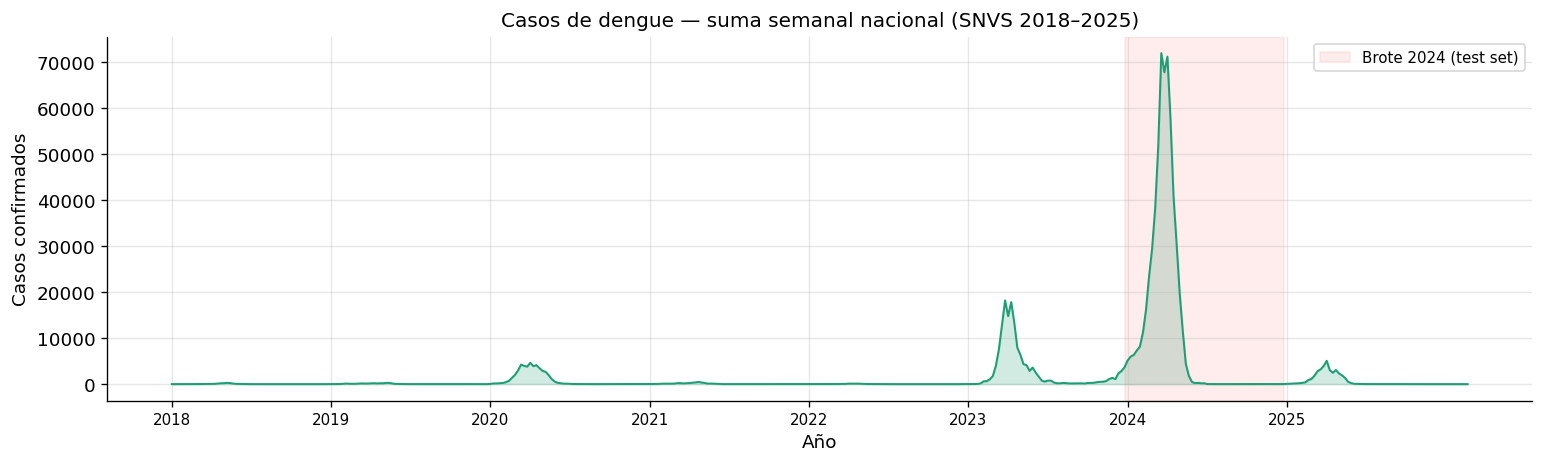

      casos_totales
anio               
2018           1576
2019           2794
2020          46437
2021           3850
2022            802
2023         146876
2024         582265
2025          35153
2026              8


In [ ]:
# Serie temporal nacional
serie = df_raw.groupby(['anio', 'semana'])['cantidad_casos'].sum().reset_index()
serie['t'] = (serie['anio'] - 2018) * 52 + serie['semana']

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(serie['t'], serie['cantidad_casos'], alpha=0.2, color=PALETTE[0])
ax.plot(serie['t'], serie['cantidad_casos'], color=PALETTE[0], linewidth=1.2)
xticks = [i * 52 + 1 for i in range(8)]
ax.set_xticks(xticks)
ax.set_xticklabels(range(2018, 2026), fontsize=9)
ax.set_xlabel('Año')
ax.set_ylabel('Casos confirmados')
ax.set_title('Casos de dengue — suma semanal nacional (SNVS 2018–2025)', fontsize=12)
ax.axvspan(6 * 52, 7 * 52, alpha=0.07, color='red', label='Brote 2024 (test set)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(df_raw.groupby('anio')['cantidad_casos'].sum().rename('casos_totales').to_frame())

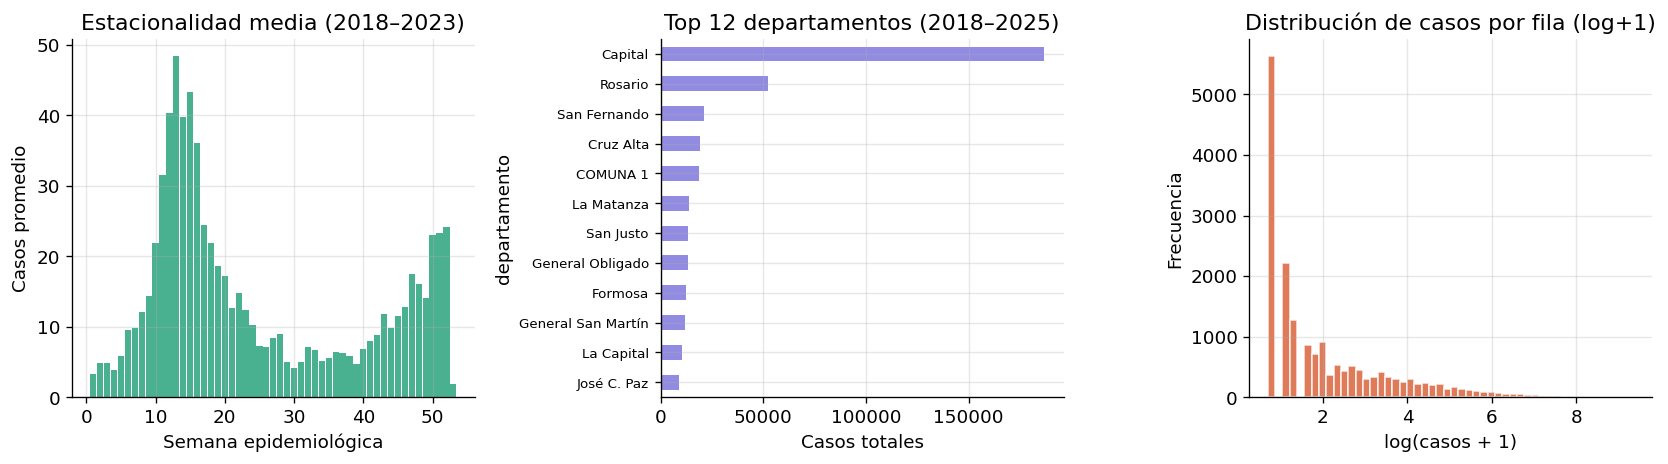

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Estacionalidad (pre-2024)
estac = df_raw[df_raw.anio < 2024].groupby('semana')['cantidad_casos'].mean()
axes[0].bar(estac.index, estac.values, color=PALETTE[0], alpha=0.8, width=0.9)
axes[0].set_title('Estacionalidad media (2018–2023)')
axes[0].set_xlabel('Semana epidemiológica')
axes[0].set_ylabel('Casos promedio')

# Top 12 departamentos
top_d = (df_raw[df_raw.departamento.str.lower() != 'desconocido']
               .groupby('departamento')['cantidad_casos']
               .sum().sort_values(ascending=True).tail(12))
top_d.plot(kind='barh', ax=axes[1], color=PALETTE[1], alpha=0.85)
axes[1].set_title('Top 12 departamentos (2018–2025)')
axes[1].set_xlabel('Casos totales')
axes[1].tick_params(axis='y', labelsize=8)

# Distribución de casos (log)
vals = df_raw[df_raw.cantidad_casos > 0]['cantidad_casos']
axes[2].hist(np.log1p(vals), bins=50, color=PALETTE[2], alpha=0.8, edgecolor='white')
axes[2].set_title('Distribución de casos por fila (log+1)')
axes[2].set_xlabel('log(casos + 1)')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

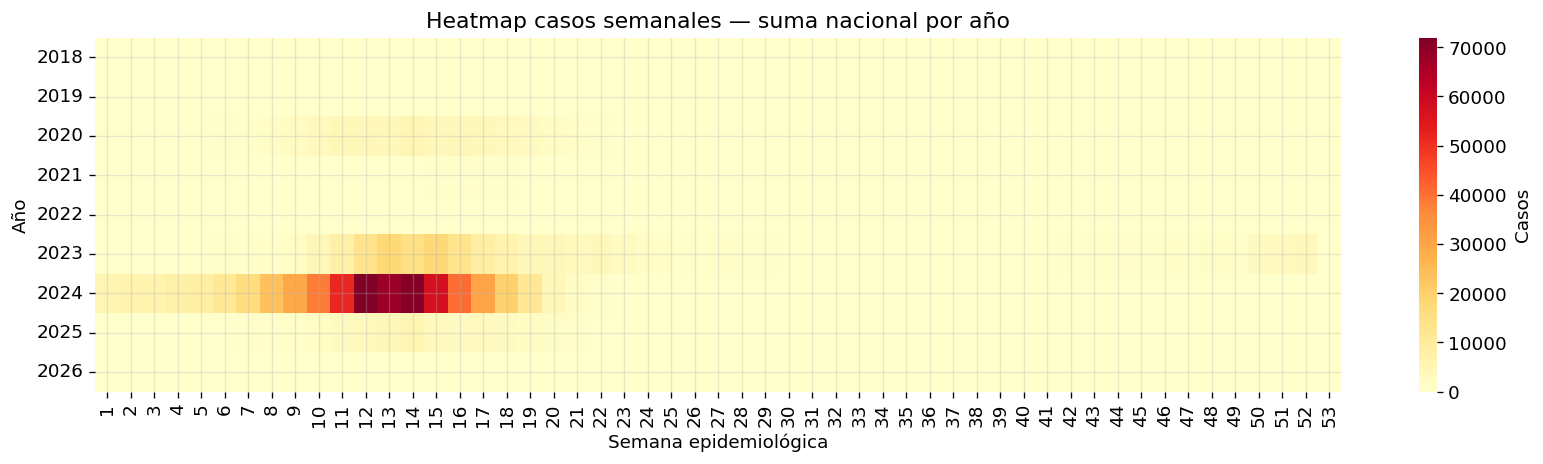

In [ ]:
# Heatmap año × semana (suma nacional)
pivot = (df_raw.groupby(['anio', 'semana'])['cantidad_casos']
               .sum().unstack('semana').fillna(0))

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0,
            cbar_kws={'label': 'Casos'})
ax.set_title('Heatmap casos semanales — suma nacional por año')
ax.set_xlabel('Semana epidemiológica')
ax.set_ylabel('Año')
plt.tight_layout()
plt.show()

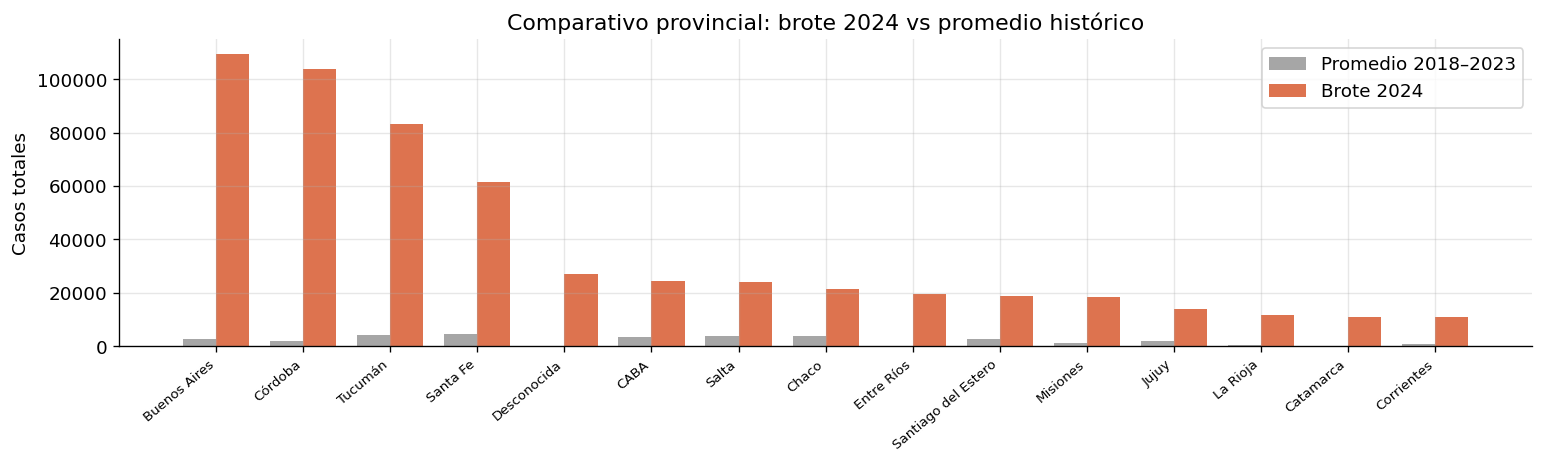

In [ ]:
# Comparativo: brote 2024 vs promedio histórico por provincia
hist  = df_raw[df_raw.anio.between(2018, 2023)].groupby('provincia')['cantidad_casos'].sum() / 6
brote = df_raw[df_raw.anio == 2024].groupby('provincia')['cantidad_casos'].sum()
comp  = pd.DataFrame({'promedio_historico': hist, 'brote_2024': brote}).fillna(0)
comp  = comp.sort_values('brote_2024', ascending=False).head(15)

x, w = np.arange(len(comp)), 0.38
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(x - w/2, comp['promedio_historico'], w, label='Promedio 2018–2023', color='gray', alpha=0.7)
ax.bar(x + w/2, comp['brote_2024'],         w, label='Brote 2024',         color=PALETTE[2], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(comp.index, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Casos totales')
ax.set_title('Comparativo provincial: brote 2024 vs promedio histórico')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Baseline y modelo candidato

- **Baseline:** media móvil de 4 SE
- **Modelo candidato:** Random Forest (300 árboles)
- **Test set:** brote 2024

In [ ]:
def mape(y_true: np.ndarray, y_pred: np.ndarray, min_casos: int = 5) -> float:
    mask = y_true >= min_casos
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


train = df_model[df_model['anio'] < 2024]
test  = df_model[df_model['anio'] == 2024]

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET].values
y_baseline = test['casos_ma4'].values.ravel()

# Baseline
mae_bl  = mean_absolute_error(y_test, y_baseline)
mape_bl = mape(y_test, y_baseline)

# Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=10,
                            min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_rf    = np.clip(rf.predict(X_test), 0, None)
mae_rf  = mean_absolute_error(y_test, y_rf)
mape_rf = mape(y_test, y_rf)

print('=== Test set: brote 2024 ===')
print(f'{"Modelo":<20} {"MAE":>8} {"MAPE (%)":>10}')
print(f'{"Baseline (MA4)":<20} {mae_bl:>8.1f} {mape_bl:>10.1f}')
print(f'{"Random Forest":<20} {mae_rf:>8.1f} {mape_rf:>10.1f}')
print(f'\nMejora MAPE: {mape_bl - mape_rf:+.1f} pp')

In [ ]:
!pip install xgboost

In [ ]:
# Ensure X_train, y_train, X_test, y_test are NumPy arrays
X_train_np = X_train.values
y_train_np = y_train.values.ravel() # .ravel() ensures it's 1D

X_test_np  = X_test.values
y_test_np  = y_test.ravel()   # .ravel() ensures it's 1D even if it came as (N, 1)

# XGBoost — activar con: pip install xgboost
import xgboost as xgb
xgb_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    objective='reg:squarederror', random_state=42, n_jobs=-1,
)
xgb_model.fit(X_train_np, y_train_np, eval_set=[(X_test_np, y_test_np)], verbose=100)
y_xgb    = np.clip(xgb_model.predict(X_test_np), 0, None)

# Calculate metrics using the 1D NumPy arrays
mae_xgb  = mean_absolute_error(y_test_np, y_xgb)
mape_xgb = mape(y_test_np, y_xgb)

print(f'XGBoost — MAE: {mae_xgb:.1f} | MAPE: {mape_xgb:.1f}%')
print('Celda XGBoost lista. Descomentar tras: pip install xgboost')

---
## 7. Validación walk-forward

Entrena con datos hasta el año *y*, predice el año *y+1*. Repite para todos los años ≥ 2020.

In [ ]:
wf_results = []
for pred_year in sorted(df_model.anio.unique()):
    if pred_year < 2020:
        continue
    tr = df_model[df_model['anio'] < pred_year]
    te = df_model[df_model['anio'] == pred_year]
    if len(tr) < 100 or len(te) == 0:
        continue
    m = RandomForestRegressor(n_estimators=150, max_depth=8,
                               min_samples_leaf=5, random_state=42, n_jobs=-1)
    m.fit(tr[FEATURE_COLS], tr[TARGET])
    pred = np.clip(m.predict(te[FEATURE_COLS]), 0, None)
    wf_results.append(
        {
            'año': pred_year,
            'n_obs': len(te),
            'mae_rf': mean_absolute_error(te[TARGET], pred),
            'mape_rf': mape(te[TARGET].values, pred),
            'mae_baseline': mean_absolute_error(te[TARGET].values, te['casos_ma4'].values[:, 0]),
            'mape_baseline': mape(te[TARGET].values, te['casos_ma4'].values.ravel())
        }
    )

df_wf = pd.DataFrame(wf_results)
df_wf['mejora_pp'] = df_wf['mape_baseline'] - df_wf['mape_rf']
print(df_wf.to_string(index=False))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(df_wf['año'], df_wf['mape_baseline'], 'o--',
             color='gray', label='Baseline (MA4)', linewidth=1.5)
axes[0].plot(df_wf['año'], df_wf['mape_rf'], 'o-',
             color=PALETTE[0], label='Random Forest', linewidth=2)
axes[0].axhline(30, color=PALETTE[2], linewidth=1,
                linestyle=':', alpha=0.8, label='Objetivo ≤ 30%')
axes[0].set_xlabel('Año de predicción')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_title('MAPE walk-forward')
axes[0].legend(fontsize=9)

colors = [PALETTE[0] if v > 0 else PALETTE[2] for v in df_wf['mejora_pp']]
axes[1].bar(df_wf['año'], df_wf['mejora_pp'], color=colors, alpha=0.85)
axes[1].axhline(0, color='gray', linewidth=0.7)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Reducción MAPE vs baseline (pp)')
axes[1].set_title('Mejora sobre baseline')

plt.tight_layout()
plt.show()

---
## 8. Resultados e interpretabilidad

In [ ]:
imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
imp.tail(15).plot(kind='barh', ax=ax, color=PALETTE[1], alpha=0.85)
ax.set_xlabel('Importancia (Gini)')
ax.set_title('Top 15 features — Random Forest')
plt.tight_layout()
plt.show()

print('Top 5:')
print(imp.tail(5).sort_values(ascending=False).to_string())

In [ ]:
# Predicción vs real para el departamento de mayor carga en 2024
deptos_2024 = test.groupby('departamento')[TARGET].sum().sort_values(ascending=False)
depto_foco  = deptos_2024.index[0]
print(f'Departamento: {depto_foco} ({deptos_2024.iloc[0]:.0f} casos en 2024)')

mask      = test['departamento'] == depto_foco
semanas_d = test.loc[mask, 'semana'].values
y_real_d  = y_test[mask.values]
y_pred_d  = y_rf[mask.values]
y_base_d  = y_baseline[mask.values]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(semanas_d, y_real_d, 'o-', color='black', linewidth=2, label='Casos reales', zorder=3)
ax.plot(semanas_d, y_pred_d, 's--', color=PALETTE[0], linewidth=1.8, label='Random Forest', zorder=2)
ax.plot(semanas_d, y_base_d, '^:', color='gray', linewidth=1.4, label='Baseline MA4', zorder=1)
ax.fill_between(semanas_d, y_pred_d * 0.7, y_pred_d * 1.3,
                alpha=0.1, color=PALETTE[0], label='Intervalo ±30%')
ax.set_xlabel('Semana epidemiológica')
ax.set_ylabel('Casos confirmados')
ax.set_title(f'{depto_foco} — predicción sobre brote 2024')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Resumen y próximos pasos

### Estado actual

| Componente | Estado |
|---|---|
| Ingesta SNVS 2018–2025 (CSV + XLSX) | ✅ Datos reales |
| Normalización automática esquema A/B | ✅ Funcionando |
| Datos climáticos NASA POWER | ⚠️ Sintéticos — descomentar fetch_nasa_power() |
| Feature engineering (20 features) | ✅ Implementado |
| Baseline media móvil | ✅ Funcionando |
| Random Forest | ✅ Funcionando |
| XGBoost | ⏳ pip install xgboost |
| Validación walk-forward 2020–2024 | ✅ Implementada |
| NDVI satelital (GEE) | ⏳ Próxima iteración |
| Censo 2022 (NBI, densidad) | ⏳ Próxima iteración |

### Próximos pasos
1. Conectar clima real: descomentar el bloque de descarga NASA POWER (sección 4)
2. `pip install xgboost` y descomentar celda en sección 6
3. Incorporar NBI y densidad del Censo 2022 como features estáticas por departamento
4. Pipeline NDVI via Google Earth Engine (cuenta gratuita para investigación)
5. Implementar corrección de subregistro (~1.5× según literatura regional)
6. Generar mapa de alertas departamental con predicciones t+2 y t+4